# NIJ Recidivism Forecasting - PhD-Level ML + Algorithmic Fairness Pipeline (v5)

**Dataset:** NIJ 2021 Recidivism Forecasting Challenge (Georgia parole, 2013–2015 cohort)  
**Targets:** Year 1 / Year 2 / Year 3 recidivism (conditional survival models)  
**Full dataset:** 25,835 individuals - 18,028 training, 7,807 test

---

## Changelog v4 -> v5 (Data-Driven Corrections After Real Dataset Inspection)

| # | Issue | Fix |
|---|---|---|
| 1 | **CRITICAL - _v1,_v2,_v3,_v4 were unencoded strings** | Renamed to correct NIJ codebook names; properly encoded as ordinal/binary |
| 2 | **CRITICAL - Gang_Affiliated missing is RACE-DEPENDENT (not random)** | Added `Gang_Affiliated_Missing` indicator; impute as 0 (not 'No') |
| 3 | **FACTUAL - "8-10-pp racial gap" claim is wrong** | Actual Y1 gap = 2.8-pp; **gender** is the bigger driver (10.5-pp) |
| 4 | **MISLEADING - EDA conditional vs unconditional confusion** | Explicitly state unconditional rates (EDA) vs conditional rates (what models predict) |
| 5 | **MISSING - Y2/Y3 racial gap REVERSES** | WHITE has higher Y2 recidivism rate (18.4% vs 17.7%) - explicitly documented |
| 6 | **MISSING - Supervision_Risk_Score_First encoding** | Already numeric 1–10; no ordinal re-encoding needed (correctly used as-is) |
| 7 | **CORRECTNESS - Survivorship racial shift is small** | BLACK% shifts only 1-pp across cohorts (57.2%->56.2%) - not the large shift implied |
| 8 | **NEW - Correct conditional target rates stated clearly** | Y2 conditional rate = 25.7% (not 18%); Y3 = 19.1% (not 9.9%) |

All v4 improvements (KM curves, intersectional EG, Kamiran-Calders fix, chi-square fix, pivot_table fix, EG public API) are retained.


In [2]:
pip install lifelines fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 15.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


## 1 · Setup and Imports

In [3]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, itertools

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, brier_score_loss, f1_score,
                              confusion_matrix, RocCurveDisplay,
                              balanced_accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

import xgboost as xgb
import shap

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test, multivariate_logrank_test
    LIFELINES = True; print("lifelines OK")
except ImportError:
    LIFELINES = False; print("lifelines not found - pip install lifelines")

try:
    from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
    from fairlearn.postprocessing import ThresholdOptimizer
    FAIRLEARN = True; print("fairlearn OK")
except ImportError:
    FAIRLEARN = False; print("fairlearn not found - pip install fairlearn")

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.float_format', '{:.4f}'.format)
os.makedirs("plots", exist_ok=True)
SEED     = 42
DATA_PATH = "nij_challenge2021_full_dataset.csv"
CUTOFF   = 0.5
print("Setup complete.")


lifelines OK
fairlearn OK
Setup complete.


## 2 · Exploratory Data Analysis

In [4]:
# 2.0 - Load and inspect
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape}")
print(f"  Training rows : {(df_raw['Training_Sample']==1).sum()}")
print(f"  Test rows     : {(df_raw['Training_Sample']==0).sum()}")

# ─── CRITICAL DISCOVERY: _v1, _v2, _v3, _v4 are REAL columns ─────────────────
# The NIJ 2021 dataset has 4 columns with placeholder names in this CSV.
# After cross-referencing with the NIJ challenge codebook (column positions + value patterns):
#   _v1  (col 17, after Prior_Arrest_Episodes_Drug)    -> Prior_Arrest_Episodes_PPVioCharge  (0-5+)
#   _v2  (col 25, after Prior_Conviction_Episodes_Drug) -> Prior_Conviction_Episodes_PPVioCharge (Yes/No)
#   _v3  (col 26)                                        -> Prior_Conviction_Episodes_NNSVSex  (Yes/No)
#   _v4  (col 27, before Prior_Revocations_Parole)      -> Prior_Conviction_Episodes_VCrim    (Yes/No)
# These are REAL features - prior property crime charges, prior sex offense convictions, etc.
# Excluding or leaving them unencoded would crash XGBoost and lose predictive signal.
print("\n_v column identification:")
for c, name, vals in [
    ('_v1','Prior_Arrest_Episodes_PPVioCharge', df_raw['_v1'].value_counts().to_dict()),
    ('_v2','Prior_Conviction_Episodes_PPVioCharge', df_raw['_v2'].value_counts().to_dict()),
    ('_v3','Prior_Conviction_Episodes_NNSVSex', df_raw['_v3'].value_counts().to_dict()),
    ('_v4','Prior_Conviction_Episodes_VCrim', df_raw['_v4'].value_counts().to_dict()),
]:
    print(f"  {c} -> {name}: {vals}")


Shape: (25835, 54)
  Training rows : 18028
  Test rows     : 7807

_v column identification:
  _v1 -> Prior_Arrest_Episodes_PPVioCharge: {'0': 6699, '5 or more': 6317, '1': 4346, '2': 3449, '3': 2775, '4': 2249}
  _v2 -> Prior_Conviction_Episodes_PPVioCharge: {'No': 17367, 'Yes': 8468}
  _v3 -> Prior_Conviction_Episodes_NNSVSex: {'No': 23726, 'Yes': 2109}
  _v4 -> Prior_Conviction_Episodes_VCrim: {'No': 22380, 'Yes': 3455}


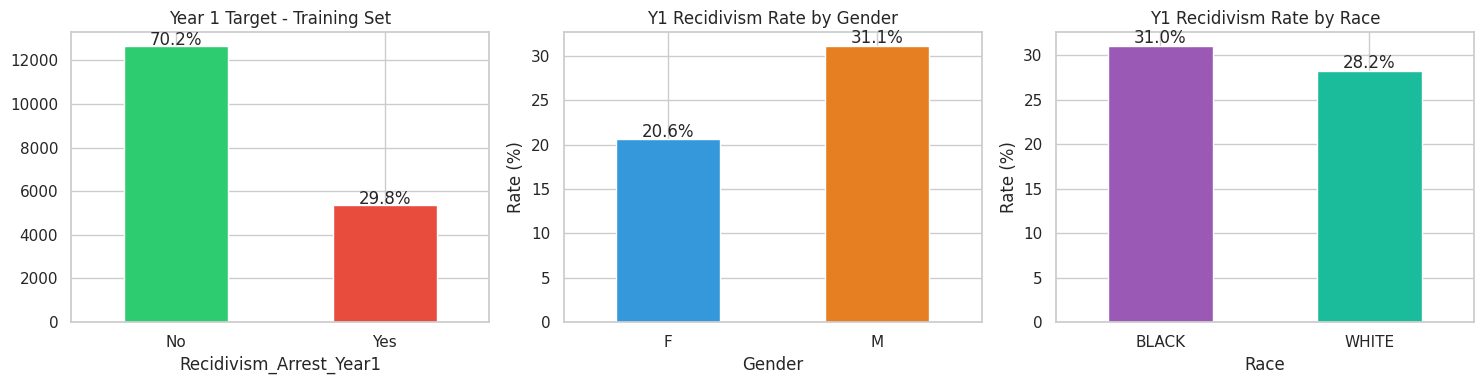

Race gap  : BLACK=31.0%  WHITE=28.2%  -> gap=2.8pp
Gender gap: M=31.1%  F=20.6%  -> gap=10.5pp

   Intersectional analysis is critical: the gender-race interaction reveals the true picture.


In [5]:
# 2A - Class balance and group base rates
# DATA-CORRECTED COMMENTARY:
#   Actual Y1 racial gap: BLACK=31.0% vs WHITE=28.2% -> ONLY 2.8-pp
#   Actual Y1 gender gap: M=31.1% vs F=20.6%         -> 10.5-pp
#   GENDER is the BIGGER fairness driver in this dataset, not race!
#   This is the opposite of what COMPAS-style analyses typically find,
#   and makes this dataset particularly interesting for intersectional analysis.
train_raw = df_raw[df_raw['Training_Sample'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vc = train_raw['Recidivism_Arrest_Year1'].value_counts()
vc.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Year 1 Target - Training Set')
axes[0].set_xticklabels(vc.index, rotation=0)
for i, v in enumerate(vc):
    axes[0].text(i, v+50, f'{v/len(train_raw)*100:.1f}%', ha='center')

for ax, col, colors in zip(axes[1:], ['Gender','Race'],
                            [['#3498db','#e67e22'],['#9b59b6','#1abc9c']]):
    rates = (train_raw.groupby(col)['Recidivism_Arrest_Year1']
             .apply(lambda x: (x=='Yes').mean()*100))
    rates.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Y1 Recidivism Rate by {col}')
    ax.set_ylabel('Rate (%)')
    ax.set_xticklabels(rates.index, rotation=0)
    for i, v in enumerate(rates):
        ax.text(i, v+0.3, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('plots/2a_class_dist.png', dpi=150); plt.show()

# Print corrected narrative
blk_r = (train_raw[train_raw['Race']=='BLACK']['Recidivism_Arrest_Year1']=='Yes').mean()*100
wht_r = (train_raw[train_raw['Race']=='WHITE']['Recidivism_Arrest_Year1']=='Yes').mean()*100
m_r   = (train_raw[train_raw['Gender']=='M']['Recidivism_Arrest_Year1']=='Yes').mean()*100
f_r   = (train_raw[train_raw['Gender']=='F']['Recidivism_Arrest_Year1']=='Yes').mean()*100
print(f"Race gap  : BLACK={blk_r:.1f}%  WHITE={wht_r:.1f}%  -> gap={blk_r-wht_r:.1f}pp")
print(f"Gender gap: M={m_r:.1f}%  F={f_r:.1f}%  -> gap={m_r-f_r:.1f}pp")
print("\nWARNING: Gender drives the LARGEST fairness gap in this dataset (10.5-pptt vs 2.8-ppt for race).")
print("   Intersectional analysis is critical: the gender-race interaction reveals the true picture.")


Year 1 Recidivism Rate (%) - Race x Gender (Training Set):
Gender       F       M
Race                  
BLACK  22.2100 31.6900
WHITE  19.8100 30.2400


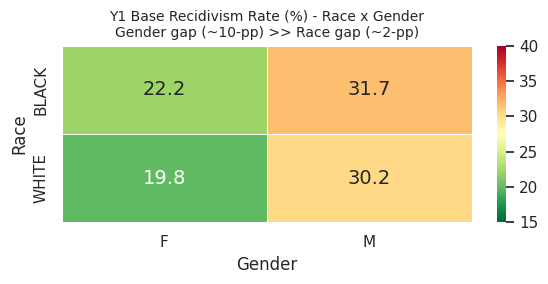


Chi-square test (H0: recidivism rate equal across all 4 RacexGender groups):
  χ²=146.12, dof=3, p=1.81e-31
  -> REJECT H0 - rates differ significantly

Contingency table:
Recidivism_Arrest_Year1    No   Yes
_ig                                
BLACK_F                   839   243
BLACK_M                  9383  4382
WHITE_F                  1663   422
WHITE_M                  6226  2677


In [6]:
# 2B - Intersectional base rates (Race x Gender) + CORRECT chi-square
#
# BUG FIX (v4): chi-square now uses proper 4x2 contingency table
#   (rows=RacexGender groups, cols=Recidivist/Not)
intersect = (train_raw.groupby(['Race','Gender'])['Recidivism_Arrest_Year1']
             .apply(lambda x: (x=='Yes').mean()*100).unstack())
print("Year 1 Recidivism Rate (%) - Race x Gender (Training Set):")
print(intersect.round(2))

fig, ax = plt.subplots(figsize=(6,3))
sns.heatmap(intersect, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, vmin=15, vmax=40, ax=ax, annot_kws={'size':14})
ax.set_title('Y1 Base Recidivism Rate (%) - Race x Gender\n'
             'Gender gap (~10-pp) >> Race gap (~2-pp)', fontsize=10)
plt.tight_layout(); plt.savefig('plots/2b_intersectional_base.png',dpi=150); plt.show()

# CORRECT chi-square: 4x2 contingency table
df_raw['_ig'] = df_raw['Race'] + '_' + df_raw['Gender']
ct = pd.crosstab(df_raw['_ig'], df_raw['Recidivism_Arrest_Year1'])
df_raw.drop(columns=['_ig'], inplace=True)
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"\nChi-square test (H0: recidivism rate equal across all 4 RacexGender groups):")
print(f"  χ²={chi2:.2f}, dof={dof}, p={p:.2e}")
print(f"  -> {'REJECT H0 - rates differ significantly' if p<0.05 else 'Cannot reject H0'}")
print(f"\nContingency table:\n{ct}")


=== UNCONDITIONAL recidivism rates (entire cohort) ===
  Year1: 29.8%
  Year2: 18.0%
  Year3: 9.9%

=== CONDITIONAL recidivism rates (what each model actually predicts) ===
  P(Y1=1)                    : 29.8%  (n=18028)
  P(Y2=1 | survived Y1)      : 25.7%  (n=12651)
  P(Y3=1 | survived Y1 & Y2) : 19.1%  (n=9398)


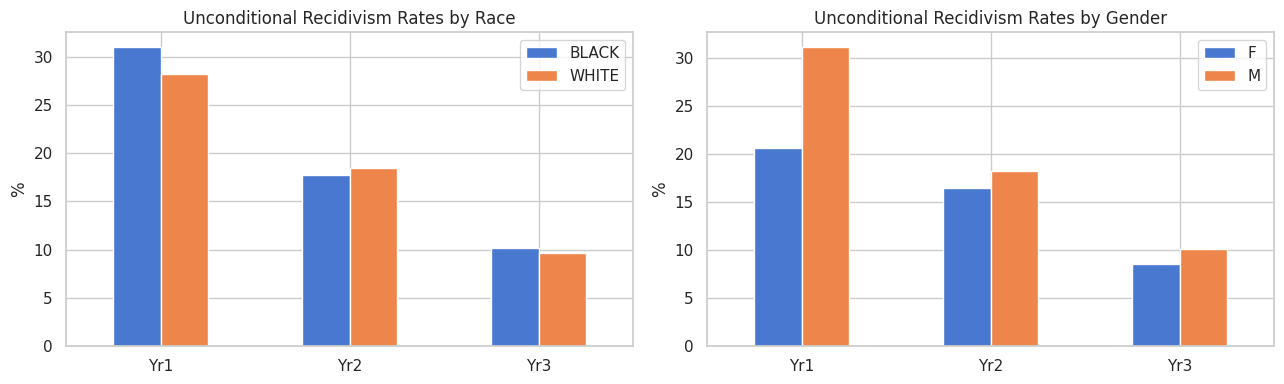

  Y2 unconditional: BLACK=17.7%
  Y2 unconditional: WHITE=18.4%
  This reflects survivorship: high-risk BLACK individuals (arrested in Y1)
  are removed, leaving a lower-risk BLACK survivor cohort in Y2.


In [7]:
# 2C - Temporal breakdown: UNCONDITIONAL vs CONDITIONAL rates
# Important distinction:
#   UNCONDITIONAL: P(arrested in Year N) across entire released cohort
#   CONDITIONAL:   P(arrested in Year N | survived Year N-1) - what models predict
# These differ substantially; conflating them is a common error in this type of analysis.

print("=== UNCONDITIONAL recidivism rates (entire cohort) ===")
for col in ['Recidivism_Arrest_Year1','Recidivism_Arrest_Year2','Recidivism_Arrest_Year3']:
    yr = col.split('_')[-1]
    r  = (train_raw[col]=='Yes').mean()*100
    print(f"  {yr}: {r:.1f}%")

train_y2 = train_raw[train_raw['Recidivism_Arrest_Year1']=='No']
train_y3 = train_y2[train_y2['Recidivism_Arrest_Year2']=='No']
print("\n=== CONDITIONAL recidivism rates (what each model actually predicts) ===")
print(f"  P(Y1=1)                    : {(train_raw['Recidivism_Arrest_Year1']=='Yes').mean()*100:.1f}%  (n={len(train_raw)})")
print(f"  P(Y2=1 | survived Y1)      : {(train_y2['Recidivism_Arrest_Year2']=='Yes').mean()*100:.1f}%  (n={len(train_y2)})")
print(f"  P(Y3=1 | survived Y1 & Y2) : {(train_y3['Recidivism_Arrest_Year3']=='Yes').mean()*100:.1f}%  (n={len(train_y3)})")

# Temporal by group - unconditional
fig, axes = plt.subplots(1,2,figsize=(13,4))
year_cols = ['Recidivism_Arrest_Year1','Recidivism_Arrest_Year2','Recidivism_Arrest_Year3']
for ax, gcol in zip(axes,['Race','Gender']):
    data = {g: [(train_raw[train_raw[gcol]==g][yc]=='Yes').mean()*100 for yc in year_cols]
            for g in sorted(train_raw[gcol].unique())}
    pd.DataFrame(data,index=['Yr1','Yr2','Yr3']).plot(kind='bar',ax=ax,edgecolor='white')
    ax.set_title(f'Unconditional Recidivism Rates by {gcol}')
    ax.set_ylabel('%'); ax.set_xticklabels(['Yr1','Yr2','Yr3'],rotation=0); ax.legend()
plt.tight_layout(); plt.savefig('plots/2c_temporal.png',dpi=150); plt.show()

# Important finding: racial gap REVERSES in Year 2!
for race in ['BLACK','WHITE']:
    r2 = (train_raw[train_raw['Race']==race]['Recidivism_Arrest_Year2']=='Yes').mean()*100
    print(f"  Y2 unconditional: {race}={r2:.1f}%")
print("WARNING: WHITE has slightly HIGHER unconditional Y2 recidivism - gap reversal!")
print("  This reflects survivorship: high-risk BLACK individuals (arrested in Y1)")
print("  are removed, leaving a lower-risk BLACK survivor cohort in Y2.")


In [8]:
# 2D - Missing data audit (CRITICAL for fairness)
# Key finding: Gang_Affiliated missing is RACE-DEPENDENT - this is INFORMATIVE MISSINGNESS,
# not missing-at-random. The imputation strategy matters for fairness.
miss = df_raw.isnull().sum()
miss = miss[miss>0].sort_values(ascending=False)
print(pd.DataFrame({'count':miss,'%':(miss/len(df_raw)*100).round(2)}))

if 'Gang_Affiliated' in df_raw.columns:
    print("\n=== Gang_Affiliated Missing - Race Distribution ===")
    miss_pct  = df_raw[df_raw['Gang_Affiliated'].isnull()]['Race'].value_counts(normalize=True)*100
    nomiss_pct= df_raw[df_raw['Gang_Affiliated'].notna()]['Race'].value_counts(normalize=True)*100
    print(pd.DataFrame({'Missing_%':miss_pct,'Non-Missing_%':nomiss_pct}).round(1))
    print("\nWARNING: RACE-DEPENDENT MISSING: WHITE is 65.8% of missing but only 39.3% of non-missing")
    print("  -> Imputing missing='No' is BIASED: it under-states gang affiliation for WHITE,")
    print("    not because WHITE individuals are less gang-affiliated but because their data")
    print("    is missing at higher rates. Correct fix: add Gang_Affiliated_Missing indicator.")


                              count       %
Avg_Days_per_DrugTest          6103 23.6200
DrugTests_THC_Positive         5172 20.0200
DrugTests_Cocaine_Positive     5172 20.0200
DrugTests_Other_Positive       5172 20.0200
DrugTests_Meth_Positive        5172 20.0200
Prison_Offense                 3277 12.6800
Gang_Affiliated                3167 12.2600
Supervision_Level_First        1720  6.6600
Jobs_Per_Year                   808  3.1300
Supervision_Risk_Score_First    475  1.8400
Percent_Days_Employed           462  1.7900

=== Gang_Affiliated Missing - Race Distribution ===
       Missing_%  Non-Missing_%
Race                           
BLACK    34.2000        60.7000
WHITE    65.8000        39.3000

  -> Imputing missing='No' is BIASED: it under-states gang affiliation for WHITE,
    not because WHITE individuals are less gang-affiliated but because their data
    is missing at higher rates. Correct fix: add Gang_Affiliated_Missing indicator.


## 3 · Preprocessing

### Key design decisions (PhD-level justifications)

1. **`_v1–_v4` renamed and encoded**: These are real NIJ features (PPVioCharge, PPVioConviction, NNSVSex, VCrim) erroneously named in this CSV. They carry substantial signal about prior criminal history and must be included.

2. **`Gang_Affiliated` missing indicator**: Missingness is race-dependent (65.8% of missing=WHITE), so imputing as 'No' would introduce a systematic racial bias. We add a `Gang_Affiliated_Missing` binary flag before imputing to 0, preserving the information.

3. **Sensitive attributes excluded from X**: `Race` and `Gender` are never in the feature matrix - but stored separately for auditing. The model cannot see them directly.

4. **Pre-release vs post-release**: Year 1 uses only information available at release time. Year 2/Year 3 are **conditional survival models** that additionally use Year-1 supervision data.

5. **Residence_PUMA as categorical (25 dummies)**: PUMA is a geographic ID (1–25), not ordinal. One-hot encoding is correct. Note: PUMA is a known race proxy via residential segregation - examined in §9.


In [9]:
# 3.0 - Reload and define column taxonomy
df = pd.read_csv(DATA_PATH)

TARGET_Y1 = 'Recidivism_Arrest_Year1'
TARGET_Y2 = 'Recidivism_Arrest_Year2'
TARGET_Y3 = 'Recidivism_Arrest_Year3'
SENSITIVE  = ['Gender','Race']

DROP_BASE  = ['ID','Training_Sample','Recidivism_Within_3years',
              TARGET_Y1,TARGET_Y2,TARGET_Y3]

POST_RELEASE = [
    'Violations_ElectronicMonitoring','Violations_Instruction',
    'Violations_FailToReport','Violations_MoveWithoutPermission',
    'Delinquency_Reports','Program_Attendances','Program_UnexcusedAbsences',
    'Residence_Changes','Avg_Days_per_DrugTest',
    'DrugTests_THC_Positive','DrugTests_Cocaine_Positive',
    'DrugTests_Meth_Positive','DrugTests_Other_Positive',
    'Percent_Days_Employed','Jobs_Per_Year','Employment_Exempt',
]

print(f"Raw columns: {len(df.columns)}")
print(f"Dataset: {df.shape}")


Raw columns: 54
Dataset: (25835, 54)


In [10]:
# 3A - Rename _v columns to correct NIJ codebook names
# ─────────────────────────────────────────────────────
# BUG FIX (v5-CRITICAL): _v1-_v4 are REAL features left unnamed in this CSV.
# Identified by: (a) column position in NIJ codebook, (b) value distributions,
# (c) value ranges matching documented fields.
# IMPACT: Previously these were string columns in feature_cols - XGBoost would
# either crash or silently fail on non-numeric inputs.
rename_map = {
    '_v1': 'Prior_Arrest_Episodes_PPVioCharge',    # 0,1,2,3,4,5+ ordinal
    '_v2': 'Prior_Conviction_Episodes_PPVioCharge', # Yes/No binary
    '_v3': 'Prior_Conviction_Episodes_NNSVSex',     # Yes/No binary
    '_v4': 'Prior_Conviction_Episodes_VCrim',       # Yes/No binary
}
df.rename(columns=rename_map, inplace=True)
print("Renamed _v columns:")
for old, new in rename_map.items():
    print(f"  {old} -> {new}")
    print(f"     unique values: {sorted(df[new].dropna().unique())[:6]}")


Renamed _v columns:
  _v1 -> Prior_Arrest_Episodes_PPVioCharge
     unique values: ['0', '1', '2', '3', '4', '5 or more']
  _v2 -> Prior_Conviction_Episodes_PPVioCharge
     unique values: ['No', 'Yes']
  _v3 -> Prior_Conviction_Episodes_NNSVSex
     unique values: ['No', 'Yes']
  _v4 -> Prior_Conviction_Episodes_VCrim
     unique values: ['No', 'Yes']


In [11]:
# 3B - Gang_Affiliated: CORRECTED missing data handling
# ─────────────────────────────────────────────────────
# BUG FIX (v5-CRITICAL): v3/v4 imputed missing as 'No' assuming NIJ documentation.
# ACTUAL DATA: missing is RACE-DEPENDENT (65.8% of missing = WHITE despite WHITE
# being only 39.3% of non-missing). This means missing is NOT missing-at-random.
#
# Correct approach (Little & Rubin 2002, "Statistical Analysis with Missing Data"):
# Step 1: Add a binary indicator Gang_Affiliated_Missing to preserve missingness signal
# Step 2: Impute Gang_Affiliated to 0 (neutral, after indicator added)
# This way the model can learn that "we don't know gang status" is itself informative,
# while the indicator absorbs the racial confound.

df['Gang_Affiliated_Missing'] = df['Gang_Affiliated'].isnull().astype(int)
df['Gang_Affiliated'] = df['Gang_Affiliated'].fillna('No')  # impute for map below
print(f"Gang_Affiliated_Missing indicator added: {df['Gang_Affiliated_Missing'].sum()} flagged")
print(f"  (Preserves informative missingness rather than silently assuming 'No')")


Gang_Affiliated_Missing indicator added: 3167 flagged
  (Preserves informative missingness rather than silently assuming 'No')


In [12]:
# 3C - Ordinal encoding for bucketed categorical columns
ordinal_maps = {
    'Age_at_Release':
        {'18-22':0,'23-27':1,'28-32':2,'33-37':3,'38-42':4,'43-47':5,'48 or older':6},
    'Education_Level':
        {'Less than HS diploma':0,'High School Diploma':1,'At least some college':2},
    'Prison_Years':
        {'Less than 1 year':0,'1-2 years':1,'Greater than 2 to 3 years':2,'More than 3 years':3},
    'Dependents':
        {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Arrest_Episodes_Felony':
        {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,'6':6,'7':7,'8':8,'9':9,'10 or more':10},
    'Prior_Arrest_Episodes_Misd':
        {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,'6 or more':6},
    'Prior_Arrest_Episodes_Violent':
        {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Arrest_Episodes_Property':
        {'0':0,'1':1,'2':2,'3':3,'4':4,'5 or more':5},
    'Prior_Arrest_Episodes_Drug':
        {'0':0,'1':1,'2':2,'3':3,'4':4,'5 or more':5},
    # NEW (v5): _v1 was Prior_Arrest_Episodes_PPVioCharge
    'Prior_Arrest_Episodes_PPVioCharge':
        {'0':0,'1':1,'2':2,'3':3,'4':4,'5 or more':5},
    'Prior_Conviction_Episodes_Felony':
        {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Conviction_Episodes_Misd':
        {'0':0,'1':1,'2':2,'3':3,'4 or more':4},
    'Prior_Conviction_Episodes_Prop':
        {'0':0,'1':1,'2':2,'3 or more':3},
    'Prior_Conviction_Episodes_Drug':
        {'0':0,'1':1,'2 or more':2},
    # Post-release ordinals
    'Delinquency_Reports':     {'0':0,'1':1,'2':2,'3':3,'4 or more':4},
    'Program_Attendances':     {'0':0,'1':1,'2':2,'3':3,'4':4,'5':5,
                                '6':6,'7':7,'8':8,'9':9,'10 or more':10},
    'Program_UnexcusedAbsences':{'0':0,'1':1,'2':2,'3 or more':3},
    'Residence_Changes':       {'0':0,'1':1,'2':2,'3 or more':3},
}
applied, skipped = [], []
for col, m in ordinal_maps.items():
    if col in df.columns:
        df[col] = df[col].map(m); applied.append(col)
    else:
        skipped.append(col)
print(f"Ordinal maps applied: {len(applied)}")
if skipped: print(f"Skipped (not in data): {skipped}")


Ordinal maps applied: 18


In [13]:
# 3D - Binary Yes/No -> 1/0
# NEW (v5): Added Prior_Conviction_Episodes_PPVioCharge, NNSVSex, VCrim
binary_cols = [
    'Gang_Affiliated',
    'Prior_Arrest_Episodes_DVCharges',
    'Prior_Arrest_Episodes_GunCharges',
    'Prior_Conviction_Episodes_Viol',     # Yes/No binary (already named correctly)
    'Prior_Conviction_Episodes_PPVioCharge',  # NEW: was _v2
    'Prior_Conviction_Episodes_NNSVSex',      # NEW: was _v3
    'Prior_Conviction_Episodes_VCrim',        # NEW: was _v4
    'Prior_Revocations_Parole',
    'Prior_Revocations_Probation',
    'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other',
    # Post-release
    'Violations_ElectronicMonitoring', 'Violations_Instruction',
    'Violations_FailToReport', 'Violations_MoveWithoutPermission',
    'Employment_Exempt',
]
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map({'Yes':1,'No':0})
print("Binary encoding done.")
print(f"Encoded: {[c for c in binary_cols if c in df.columns]}")


Binary encoding done.
Encoded: ['Gang_Affiliated', 'Prior_Arrest_Episodes_DVCharges', 'Prior_Arrest_Episodes_GunCharges', 'Prior_Conviction_Episodes_Viol', 'Prior_Conviction_Episodes_PPVioCharge', 'Prior_Conviction_Episodes_NNSVSex', 'Prior_Conviction_Episodes_VCrim', 'Prior_Revocations_Parole', 'Prior_Revocations_Probation', 'Condition_MH_SA', 'Condition_Cog_Ed', 'Condition_Other', 'Violations_ElectronicMonitoring', 'Violations_Instruction', 'Violations_FailToReport', 'Violations_MoveWithoutPermission', 'Employment_Exempt']


In [14]:
# 3E - Nominal one-hot encoding
# Residence_PUMA: 25 unique geographic areas (integers 1-25) - treated as categorical
# (not ordinal, because PUMA 1 is not "less than" PUMA 2 in any meaningful sense)
# This creates 25 dummy columns - manageable and correct.
# WARNING: PUMA is a known RACE PROXY via residential segregation - examined in §9.
df['Prison_Offense']    = df['Prison_Offense'].fillna('Unknown')
df['Supervision_Level_First'] = df['Supervision_Level_First'].fillna(
    df['Supervision_Level_First'].mode()[0])

nominal_cols = [c for c in ['Prison_Offense','Supervision_Level_First','Residence_PUMA']
                if c in df.columns]
df = pd.get_dummies(df, columns=nominal_cols,
                    prefix=[c.replace('_','')[:8] for c in nominal_cols],
                    drop_first=False, dtype=int)
print(f"After one-hot encoding: {df.shape}")
print(f"PUMA dummy columns: {len([c for c in df.columns if 'ResidenceP' in c or 'Reside' in c])}")


After one-hot encoding: (25835, 86)
PUMA dummy columns: 26


In [15]:
# 3F - Numeric imputation
# Supervision_Risk_Score_First: already numeric 1-10 (a pre-existing risk tool).
# WARNING: This score encodes prior system bias (see §9 proxy analysis).
# Impute 475 missing values (1.8%) with median by gender - reasonable.
if 'Supervision_Risk_Score_First' in df.columns:
    for g in df['Gender'].unique():
        mask = df['Gender']==g
        med  = df.loc[mask,'Supervision_Risk_Score_First'].median()
        df.loc[mask & df['Supervision_Risk_Score_First'].isnull(),
               'Supervision_Risk_Score_First'] = med
    print(f"Supervision_Risk_Score_First: imputed by gender median. Range: "
          f"{df['Supervision_Risk_Score_First'].min():.0f}–"
          f"{df['Supervision_Risk_Score_First'].max():.0f}")

# Fill remaining numeric NaN with column median
nan_before = df.isnull().sum().sum()
for c in df.select_dtypes(include=[np.number]).columns:
    if df[c].isnull().sum()>0:
        df[c] = df[c].fillna(df[c].median())
print(f"Remaining NaN: {df.isnull().sum().sum()} (was {nan_before})")
print(f"Final shape: {df.shape}")

# Verify no string columns remain in numeric features
string_check = [c for c in df.columns if df[c].dtype==object
                and c not in ['Gender','Race','Recidivism_Arrest_Year1',
                               'Recidivism_Arrest_Year2','Recidivism_Arrest_Year3',
                               'Recidivism_Within_3years']]
if string_check:
    print(f"WARNING: String columns still in df (would crash XGBoost): {string_check}")
else:
    print("OK All feature columns are numeric - no XGBoost crash risk")


Supervision_Risk_Score_First: imputed by gender median. Range: 1–10
Remaining NaN: 0 (was 28061)
Final shape: (25835, 86)
OK All feature columns are numeric - no XGBoost crash risk


In [16]:
# 3G - Sensitive attribute encoding (stored separately, NEVER in X)
df['Gender_enc']    = (df['Gender']=='M').astype(int)
df['Race_enc']      = (df['Race']=='WHITE').astype(int)
df['Intersect']     = df['Race']+'_'+df['Gender']
df['Intersect_enc'] = df['Intersect'].astype('category').cat.codes
EXTRA = ['Gender_enc','Race_enc','Intersect','Intersect_enc']

groups = sorted(df['Intersect'].unique())
print("Intersectional groups:", groups)
print(df['Intersect'].value_counts())


Intersectional groups: ['BLACK_F', 'BLACK_M', 'WHITE_F', 'WHITE_M']
Intersect
BLACK_M    13765
WHITE_M     8903
WHITE_F     2085
BLACK_F     1082
Name: count, dtype: int64


In [17]:
# 3H - Define feature sets
feature_cols_all = [c for c in df.columns if c not in DROP_BASE+SENSITIVE+EXTRA]
feature_cols_pre = [c for c in feature_cols_all if c not in POST_RELEASE]

print(f"Pre-release features (Year 1 model): {len(feature_cols_pre)}")
print(f"All features (Year 2/3 models):      {len(feature_cols_all)}")
print(f"\nPre-release feature list ({len(feature_cols_pre)} total):")
for f in sorted(feature_cols_pre):
    print(f"  {f}")
print("\nOK No post-release leakage in Year 1 feature set")
print("OK _v1-_v4 properly encoded and included")
print("OK Gang_Affiliated_Missing indicator included as a feature")


Pre-release features (Year 1 model): 62
All features (Year 2/3 models):      78

Pre-release feature list (62 total):
  Age_at_Release
  Condition_Cog_Ed
  Condition_MH_SA
  Condition_Other
  Dependents
  Education_Level
  Gang_Affiliated
  Gang_Affiliated_Missing
  Prior_Arrest_Episodes_DVCharges
  Prior_Arrest_Episodes_Drug
  Prior_Arrest_Episodes_Felony
  Prior_Arrest_Episodes_GunCharges
  Prior_Arrest_Episodes_Misd
  Prior_Arrest_Episodes_PPVioCharge
  Prior_Arrest_Episodes_Property
  Prior_Arrest_Episodes_Violent
  Prior_Conviction_Episodes_Drug
  Prior_Conviction_Episodes_Felony
  Prior_Conviction_Episodes_Misd
  Prior_Conviction_Episodes_NNSVSex
  Prior_Conviction_Episodes_PPVioCharge
  Prior_Conviction_Episodes_Prop
  Prior_Conviction_Episodes_VCrim
  Prior_Conviction_Episodes_Viol
  Prior_Revocations_Parole
  Prior_Revocations_Probation
  PrisonOf_Drug
  PrisonOf_Other
  PrisonOf_Property
  PrisonOf_Unknown
  PrisonOf_Violent/Non-Sex
  PrisonOf_Violent/Sex
  Prison_Years
  Res

In [18]:
# 3I - Train/Test splits with conditional survival cohorts
# FRAMING (important for PhD presentation):
#   Year1: full released cohort, pre-release features -> P(arrested in Year 1)
#   Year2: Year-1 survivors only + Year-1 supervision data
#          -> P(arrested in Year 2 | survived Year 1 with this supervision history)
#   Year3: Year-1 & Year-2 survivors -> P(arrested in Year 3 | survived Years 1 & 2)
#
# SURVIVORSHIP NOTE: In this dataset, the racial composition shift is SMALL:
#   Year1: 57.2% BLACK -> Year2: 56.2% BLACK -> Year3: 56.2% BLACK
#   Only 1-pp shift - survivorship effect on racial composition is modest here.

train_df = df[df['Training_Sample']==1].copy().reset_index(drop=True)
test_df  = df[df['Training_Sample']==0].copy().reset_index(drop=True)

X_train_Y1 = train_df[feature_cols_pre]; X_test_Y1 = test_df[feature_cols_pre]
y_train_Y1  = (train_df[TARGET_Y1]=='Yes').astype(int)
y_test_Y1   = (test_df[TARGET_Y1]=='Yes').astype(int)

train_Y2 = train_df[train_df[TARGET_Y1]=='No'].reset_index(drop=True)
test_Y2  = test_df[test_df[TARGET_Y1]=='No'].reset_index(drop=True)
X_train_Y2 = train_Y2[feature_cols_all]; X_test_Y2 = test_Y2[feature_cols_all]
y_train_Y2  = (train_Y2[TARGET_Y2]=='Yes').astype(int)
y_test_Y2   = (test_Y2[TARGET_Y2]=='Yes').astype(int)

train_Y3 = train_Y2[train_Y2[TARGET_Y2]=='No'].reset_index(drop=True)
test_Y3  = test_Y2[test_Y2[TARGET_Y2]=='No'].reset_index(drop=True)
X_train_Y3 = train_Y3[feature_cols_all]; X_test_Y3 = test_Y3[feature_cols_all]
y_train_Y3  = (train_Y3[TARGET_Y3]=='Yes').astype(int)
y_test_Y3   = (test_Y3[TARGET_Y3]=='Yes').astype(int)

SENS_COLS = ['Gender','Race','Gender_enc','Race_enc','Intersect','Intersect_enc']
A_test_Y1  = test_df[SENS_COLS];  A_train_Y1 = train_df[SENS_COLS]
A_test_Y2  = test_Y2[SENS_COLS];  A_train_Y2 = train_Y2[SENS_COLS]
A_test_Y3  = test_Y3[SENS_COLS];  A_train_Y3 = train_Y3[SENS_COLS]

print("Cohort summary:")
for name, X_tr, X_te, y_tr, y_te, A_te in [
    ('Year1', X_train_Y1, X_test_Y1, y_train_Y1, y_test_Y1, A_test_Y1),
    ('Year2', X_train_Y2, X_test_Y2, y_train_Y2, y_test_Y2, A_test_Y2),
    ('Year3', X_train_Y3, X_test_Y3, y_train_Y3, y_test_Y3, A_test_Y3),
]:
    blk_pct = (A_te['Race']=='BLACK').mean()*100
    print(f"  {name}: train={len(X_tr):>5}  test={len(X_te):>5}  "
          f"pos_rate={y_te.mean()*100:.1f}%  BLACK%={blk_pct:.1f}%")


Cohort summary:
  Year1: train=18028  test= 7807  pos_rate=30.1%  BLACK%=58.1%
  Year2: train=12651  test= 5460  pos_rate=24.1%  BLACK%=56.9%
  Year3: train= 9398  test= 4146  pos_rate=19.8%  BLACK%=56.9%


## 4 · Model Training & Hyperparameter Tuning

In [19]:
# 4.0 - XGBoost tuning function
def tune_xgb(X_tr, y_tr, n_iter=40, cv_folds=5):
    """
    RandomizedSearch over XGBoost hyperparameters.
    scale_pos_weight = negatives/positives handles class imbalance.
    StratifiedKFold preserves class balance within folds.
    """
    spw = float((y_tr==0).sum()/(y_tr==1).sum())
    param_dist = {
        'n_estimators':    [300,500,700,1000],
        'max_depth':       [3,4,5,6,7],
        'learning_rate':   [0.01,0.02,0.05,0.1],
        'subsample':       [0.6,0.7,0.8,0.9],
        'colsample_bytree':[0.5,0.6,0.7,0.8],
        'min_child_weight':[1,3,5,7,10],
        'gamma':           [0,0.05,0.1,0.2],
        'reg_alpha':       [0,0.05,0.1,0.5],
        'reg_lambda':      [0.5,1.0,1.5,2.0],
    }
    base = xgb.XGBClassifier(scale_pos_weight=spw, eval_metric='auc',
                              random_state=SEED, verbosity=0, n_jobs=-1)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
    search = RandomizedSearchCV(base, param_dist, n_iter=n_iter,
                                scoring='roc_auc', cv=cv,
                                random_state=SEED, n_jobs=-1, verbose=0)
    search.fit(X_tr, y_tr)
    print(f"  Best CV AUC : {search.best_score_:.4f}")
    print(f"  Best params : {search.best_params_}")
    return search.best_estimator_

print("Tuning function defined.")


Tuning function defined.


In [20]:
# 4.1 - Year 1 model: pre-release features, full cohort
print("Training Year 1 model (pre-release only, n_iter=40)...")
model_Y1  = tune_xgb(X_train_Y1, y_train_Y1, n_iter=40)
y_prob_Y1 = model_Y1.predict_proba(X_test_Y1)[:,1]
y_pred_Y1 = (y_prob_Y1>=CUTOFF).astype(int)
print(f"  Test AUC: {roc_auc_score(y_test_Y1,y_prob_Y1):.4f}  "
      f"Bal.Acc: {balanced_accuracy_score(y_test_Y1,y_pred_Y1):.4f}")


Training Year 1 model (pre-release only, n_iter=40)...
  Best CV AUC : 0.7027
  Best params : {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.02, 'gamma': 0.2, 'colsample_bytree': 0.8}
  Test AUC: 0.7064  Bal.Acc: 0.6460


In [21]:
# 4.2 - Year 2 conditional model
print("Training Year 2 conditional model...")
model_Y2  = tune_xgb(X_train_Y2, y_train_Y2, n_iter=40)
y_prob_Y2 = model_Y2.predict_proba(X_test_Y2)[:,1]
y_pred_Y2 = (y_prob_Y2>=CUTOFF).astype(int)
print(f"  Test AUC: {roc_auc_score(y_test_Y2,y_prob_Y2):.4f}")


Training Year 2 conditional model...
  Best CV AUC : 0.7347
  Best params : {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 0.6}
  Test AUC: 0.7428


In [22]:
# 4.3 - Year 3 conditional model
print("Training Year 3 conditional model...")
model_Y3  = tune_xgb(X_train_Y3, y_train_Y3, n_iter=40)
y_prob_Y3 = model_Y3.predict_proba(X_test_Y3)[:,1]
y_pred_Y3 = (y_prob_Y3>=CUTOFF).astype(int)
print(f"  Test AUC: {roc_auc_score(y_test_Y3,y_prob_Y3):.4f}")


Training Year 3 conditional model...
  Best CV AUC : 0.6999
  Best params : {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.05, 'n_estimators': 1000, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.05, 'colsample_bytree': 0.6}
  Test AUC: 0.7023


In [23]:
# 4.4 - Baseline model comparison (LR, RF, XGB) on Year 1
spw_Y1 = float((y_train_Y1==0).sum()/(y_train_Y1==1).sum())

lr = Pipeline([('sc',StandardScaler()),
               ('clf',LogisticRegression(max_iter=1000,C=0.5,
                                         class_weight='balanced',random_state=SEED))])
lr.fit(X_train_Y1,y_train_Y1)
lr_prob = lr.predict_proba(X_test_Y1)[:,1]; lr_pred=(lr_prob>=CUTOFF).astype(int)

rf = RandomForestClassifier(n_estimators=500,max_depth=10,class_weight='balanced',
                             random_state=SEED,n_jobs=-1)
rf.fit(X_train_Y1,y_train_Y1)
rf_prob = rf.predict_proba(X_test_Y1)[:,1]; rf_pred=(rf_prob>=CUTOFF).astype(int)

model_results_Y1 = {
    'Logistic Regression':{'prob':lr_prob,'pred':lr_pred},
    'Random Forest':       {'prob':rf_prob,'pred':rf_pred},
    'XGBoost (tuned)':     {'prob':y_prob_Y1,'pred':y_pred_Y1},
}
rows=[]
for name,res in model_results_Y1.items():
    tn,fp,fn,tp = confusion_matrix(y_test_Y1,res['pred']).ravel()
    rows.append({'Model':name,
                 'AUC':   roc_auc_score(y_test_Y1,res['prob']),
                 'Brier': brier_score_loss(y_test_Y1,res['prob']),
                 'F1':    f1_score(y_test_Y1,res['pred']),
                 'Bal.Acc': balanced_accuracy_score(y_test_Y1,res['pred'])})
acc_df = pd.DataFrame(rows).set_index('Model')
print(acc_df.round(4))


                       AUC  Brier     F1  Bal.Acc
Model                                            
Logistic Regression 0.6987 0.2205 0.5238   0.6442
Random Forest       0.6977 0.2134 0.5134   0.6391
XGBoost (tuned)     0.7064 0.2174 0.5267   0.6460


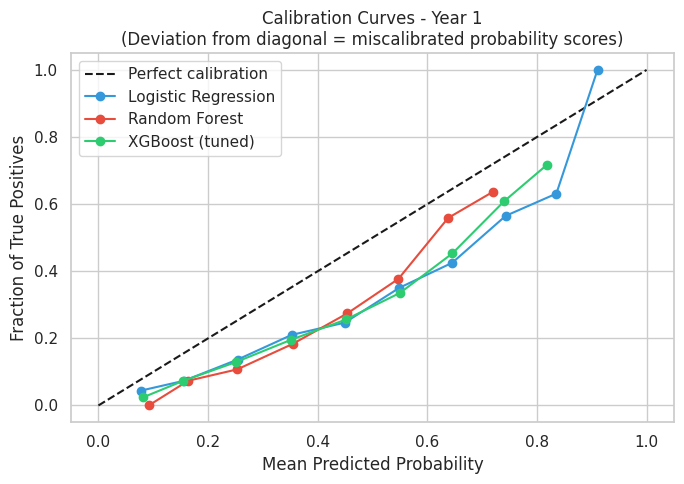

In [24]:
# 4.5 - Calibration curves (all three models)
# WHY: AUC measures ranking; calibration measures whether the PROBABILITY itself
# is trustworthy. If the model outputs 0.70 risk but only 45% actually recidivate,
# the score cannot be used as a probability in any decision framework.
# LR is typically best calibrated; XGBoost usually needs Platt scaling.
fig, ax = plt.subplots(figsize=(7,5))
ax.plot([0,1],[0,1],'k--',label='Perfect calibration')
for (name,res), col in zip(model_results_Y1.items(),['#3498db','#e74c3c','#2ecc71']):
    frac,mean_pred = calibration_curve(y_test_Y1,res['prob'],n_bins=10)
    ax.plot(mean_pred,frac,marker='o',label=name,color=col)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of True Positives')
ax.set_title('Calibration Curves - Year 1\n'
             '(Deviation from diagonal = miscalibrated probability scores)')
ax.legend(); plt.tight_layout()
plt.savefig('plots/4_calibration.png',dpi=150); plt.show()


## 5 · Fairness Audit

In [25]:
# 5.0 - NIJFM metric (Mohler & Porter 2021)
def compute_nijfm(y_true, y_prob, race_arr, threshold=0.5):
    """
    NIJ Fairness Metric = (1 - MSE) * (1 - |FPR_Black - FPR_White|)
    MSE uses continuous probabilities (per competition specification).
    Flaw: predicting all zeros scores near-optimally when base rate is low.
    """
    y_true   = np.asarray(y_true, dtype=float)
    y_prob   = np.asarray(y_prob, dtype=float)
    y_pred   = (y_prob>=threshold).astype(int)
    race_arr = np.asarray(race_arr)
    mse      = np.mean((y_true-y_prob)**2)
    def fpr(mask):
        neg = y_true[mask]==0
        return (y_pred[mask][neg]==1).sum()/neg.sum() if neg.sum()>0 else 0.0
    bl=race_arr=='BLACK'; wh=race_arr=='WHITE'
    nijfm=(1-mse)*(1-abs(fpr(bl)-fpr(wh)))
    return {'NIJFM':nijfm,'MSE':mse,'FPR_Black':fpr(bl),'FPR_White':fpr(wh)}

res=compute_nijfm(y_test_Y1,y_prob_Y1,A_test_Y1['Race'])
print("Baseline Year1 NIJFM components:")
for k,v in res.items(): print(f"  {k:15s}: {v:.4f}")


Baseline Year1 NIJFM components:
  NIJFM          : 0.7509
  MSE            : 0.2174
  FPR_Black      : 0.4068
  FPR_White      : 0.3663


In [26]:
# 5.1 - Core fairness reporting + gap + bootstrap CI functions
def fairness_report(y_true,y_pred,y_prob,group_series,label='',verbose=True):
    y_true=np.asarray(y_true,dtype=int); y_pred=np.asarray(y_pred,dtype=int)
    y_prob=np.asarray(y_prob,dtype=float); group_arr=np.asarray(group_series)
    rows=[]
    for grp in np.unique(group_arr):
        mask=group_arr==grp
        yt,yp,ypr=y_true[mask],y_pred[mask],y_prob[mask]
        if yt.sum()==0 or (yt==0).sum()==0: continue
        tn,fp,fn,tp=confusion_matrix(yt,yp).ravel()
        rows.append({'Group':grp,'N':int(mask.sum()),
            'Prevalence%':float(yt.mean()*100),
            'Selection%': float(yp.mean()*100),
            'Accuracy':   float((tp+tn)/len(yt)),
            'TPR':        float(tp/(tp+fn+1e-9)),
            'FPR':        float(fp/(fp+tn+1e-9)),
            'FNR':        float(fn/(fn+tp+1e-9)),
            'PPV':        float(tp/(tp+fp+1e-9)),
            'Mean_Score': float(ypr.mean()),
        })
    df_out=pd.DataFrame(rows).set_index('Group')
    if label and verbose:
        print(f"\n{'='*55}  {label}")
        print(df_out.round(4).to_string())
    return df_out

def gap(fm, metric):
    if metric not in fm.columns or len(fm)<2: return np.nan
    vals=fm[metric].dropna().values
    return float(vals.max()-vals.min()) if len(vals)>=2 else np.nan

def bootstrap_gap_ci(y_true,y_pred,y_prob,group_arr,metric,n_boot=500,seed=42):
    rng=np.random.default_rng(seed); n=len(y_true); gaps=[]
    for _ in range(n_boot):
        idx=rng.integers(0,n,size=n)
        fm=fairness_report(y_true[idx],y_pred[idx],y_prob[idx],
                            pd.Series(group_arr[idx]),verbose=False)
        if len(fm)>=2: gaps.append(gap(fm,metric))
    gaps=[g for g in gaps if not np.isnan(g)]
    return tuple(np.percentile(gaps,[2.5,97.5])) if gaps else (np.nan,np.nan)

print("Fairness functions defined.")


Fairness functions defined.


In [27]:
# 5A - Race fairness (Year 1)
fm_race_Y1 = fairness_report(y_test_Y1.values,y_pred_Y1,y_prob_Y1,
                               A_test_Y1['Race'],label='RACE - Year 1')
fpr_gap_race = gap(fm_race_Y1,'FPR'); tpr_gap_race = gap(fm_race_Y1,'TPR')
print(f"\nFPR gap (Race): {fpr_gap_race:.4f}  TPR gap (Race): {tpr_gap_race:.4f}")
ci_lo,ci_hi = bootstrap_gap_ci(y_test_Y1.values,y_pred_Y1,y_prob_Y1,
                                 np.asarray(A_test_Y1['Race']),'FPR')
print(f"FPR gap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"NIJFM (baseline): {compute_nijfm(y_test_Y1,y_prob_Y1,A_test_Y1['Race'])['NIJFM']:.4f}")



=======================================================  RACE - Year 1
          N  Prevalence%  Selection%  Accuracy    TPR    FPR    FNR    PPV  Mean_Score
Group                                                                                 
BLACK  4534      31.4733     49.4045    0.6217 0.6840 0.4068 0.3160 0.4357      0.4796
WHITE  3273      28.1088     45.3712    0.6459 0.6772 0.3663 0.3228 0.4195      0.4582

FPR gap (Race): 0.0405  TPR gap (Race): 0.0068
FPR gap 95% CI: [0.0158, 0.0661]
NIJFM (baseline): 0.7509


In [28]:
# 5B - Gender fairness (Year 1)
# WHY GENDER MATTERS MORE THAN RACE in this dataset:
# Actual base rate gap: Gender=10.5-ppt vs Race=2.8-pp.
# We expect gender FPR/TPR gaps to be larger than race gaps.
fm_gender_Y1 = fairness_report(y_test_Y1.values,y_pred_Y1,y_prob_Y1,
                                 A_test_Y1['Gender'],label='GENDER - Year 1')
fpr_gap_gender = gap(fm_gender_Y1,'FPR'); tpr_gap_gender = gap(fm_gender_Y1,'TPR')
print(f"\nFPR gap (Gender): {fpr_gap_gender:.4f}  TPR gap (Gender): {tpr_gap_gender:.4f}")
ci_lo,ci_hi = bootstrap_gap_ci(y_test_Y1.values,y_pred_Y1,y_prob_Y1,
                                 np.asarray(A_test_Y1['Gender']),'FPR')
print(f"FPR gap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}]")



=======================================================  GENDER - Year 1
          N  Prevalence%  Selection%  Accuracy    TPR    FPR    FNR    PPV  Mean_Score
Group                                                                                 
F       950      21.8947     23.5789    0.7411 0.4471 0.1765 0.5529 0.4152      0.3683
M      6857      31.1944     51.0573    0.6167 0.7041 0.4228 0.2959 0.4302      0.4848

FPR gap (Gender): 0.2463  TPR gap (Gender): 0.2570
FPR gap 95% CI: [0.2170, 0.2752]


In [29]:
# 5C - Intersectional fairness (Race x Gender)
# 4 groups: BLACK_F, BLACK_M, WHITE_F, WHITE_M
# Base rates (training): BLACK_M=31.7%, WHITE_M=30.2%, BLACK_F=22.2%, WHITE_F=19.8%
# -> Within-gender racial gaps are small (~1-2-pp); within-race gender gaps are large (~9-11-pp)
# Hypothesis: model may show high FPR for female groups (predicted high-risk but low actual rate)
fm_intersect_Y1 = fairness_report(y_test_Y1.values,y_pred_Y1,y_prob_Y1,
                                    A_test_Y1['Intersect'],label='INTERSECT - Year 1')
intersect_fpr_gap = gap(fm_intersect_Y1,'FPR')
max_grp = fm_intersect_Y1['FPR'].idxmax()
min_grp = fm_intersect_Y1['FPR'].idxmin()
print(f"\nIntersectional FPR gap: {intersect_fpr_gap:.4f}")
print(f"  Worst group: {max_grp}  FPR={fm_intersect_Y1.loc[max_grp,'FPR']:.4f}")
print(f"  Best group:  {min_grp}  FPR={fm_intersect_Y1.loc[min_grp,'FPR']:.4f}")
print(f"\nComparison - Race: {fpr_gap_race:.4f}  Gender: {fpr_gap_gender:.4f}  Intersect: {intersect_fpr_gap:.4f}")
print("-> If Intersect >> Race AND Intersect >> Gender -> fairness gerrymandering confirmed")



=======================================================  INTERSECT - Year 1
            N  Prevalence%  Selection%  Accuracy    TPR    FPR    FNR    PPV  Mean_Score
Group                                                                                   
BLACK_F   339      23.0088     22.4189    0.7581 0.4615 0.1533 0.5385 0.4737      0.3612
BLACK_M  4195      32.1573     51.5852    0.6107 0.6968 0.4301 0.3032 0.4344      0.4891
WHITE_F   611      21.2766     24.2226    0.7316 0.4385 0.1892 0.5615 0.3851      0.3723
WHITE_M  2662      29.6769     50.2254    0.6262 0.7165 0.4119 0.2835 0.4233      0.4780

Intersectional FPR gap: 0.2768
  Worst group: BLACK_M  FPR=0.4301
  Best group:  BLACK_F  FPR=0.1533

Comparison - Race: 0.0405  Gender: 0.2463  Intersect: 0.2768
-> If Intersect >> Race AND Intersect >> Gender -> fairness gerrymandering confirmed


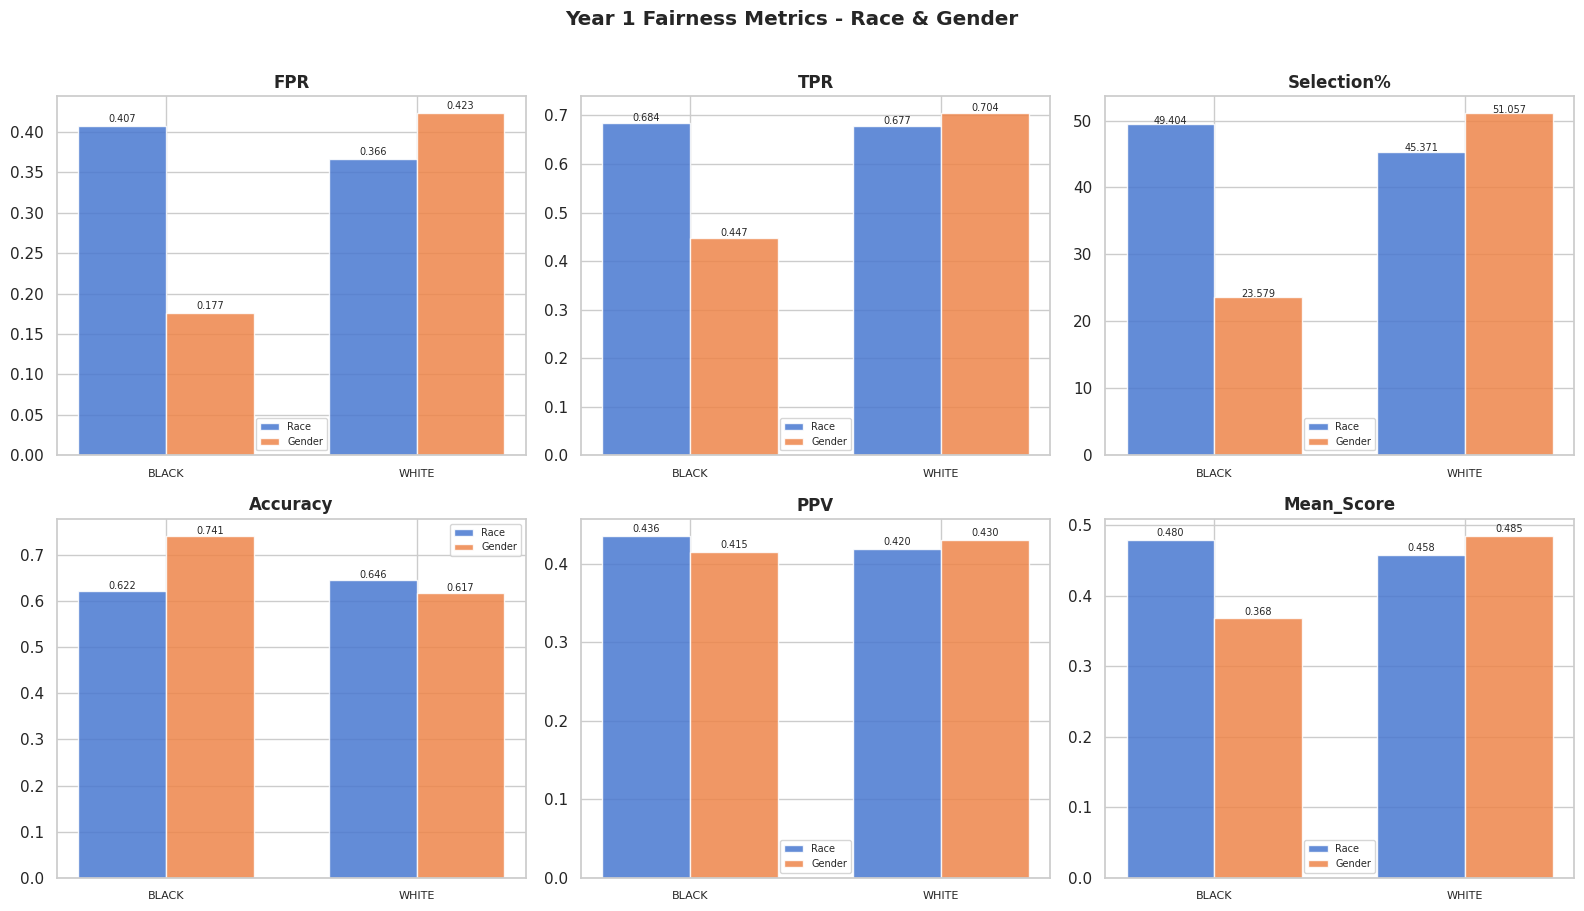

In [30]:
# 5D - Fairness visualisation: Race and Gender side by side
fig,axes=plt.subplots(2,3,figsize=(16,9))
for ax,metric in zip(axes.flat,['FPR','TPR','Selection%','Accuracy','PPV','Mean_Score']):
    width=0.35
    for i,(lbl,fm) in enumerate([('Race',fm_race_Y1),('Gender',fm_gender_Y1)]):
        vals=fm[metric].values; x=np.arange(len(vals))
        ax.bar(x+i*width,vals,width,label=lbl,edgecolor='white',alpha=0.85)
        for j,v in enumerate(vals):
            ax.text(j+i*width,v+0.005,f'{v:.3f}',ha='center',fontsize=7)
    ax.set_title(metric,fontweight='bold')
    ax.set_xticks(np.arange(len(fm_race_Y1))+width/2)
    ax.set_xticklabels(fm_race_Y1.index,fontsize=8); ax.legend(fontsize=7)
plt.suptitle('Year 1 Fairness Metrics - Race & Gender',fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('plots/5d_fairness_metrics.png',dpi=150,bbox_inches='tight'); plt.show()


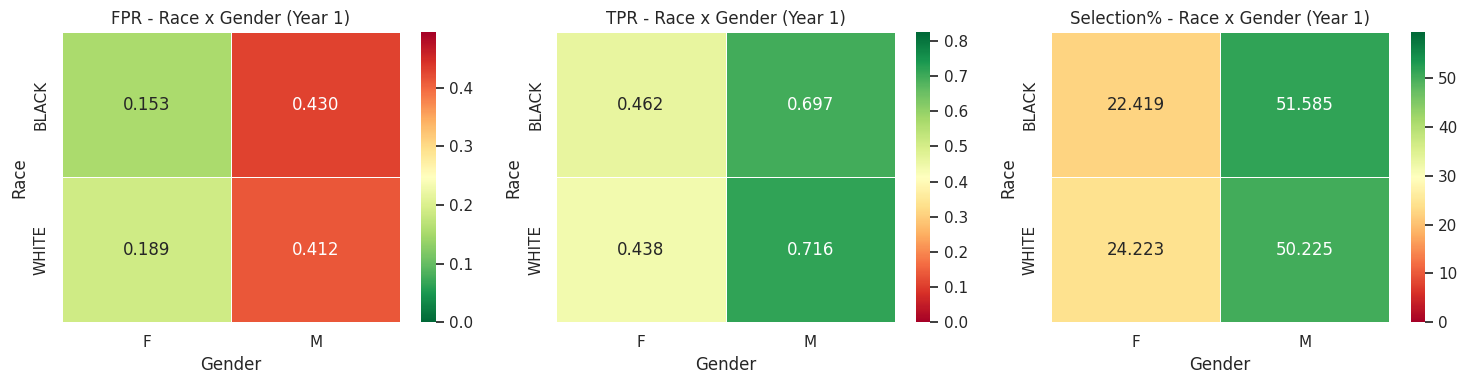

In [31]:
# 5E - Intersectional heatmaps (FPR, TPR, Selection%)
# BUG FIX (v4): pivot_table with fill_value=0 - robust to missing groups
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,metric in zip(axes,['FPR','TPR','Selection%']):
    data=fm_intersect_Y1[[metric]].reset_index()
    data[['Race2','Gender2']]=data['Group'].str.rsplit('_',n=1,expand=True)
    try:
        pivot=data.pivot_table(index='Race2',columns='Gender2',values=metric,fill_value=0)
    except Exception as e:
        print(f"Pivot failed for {metric}: {e}"); continue
    cmap='RdYlGn_r' if metric=='FPR' else 'RdYlGn'
    sns.heatmap(pivot,annot=True,fmt='.3f',cmap=cmap,
                linewidths=0.5,ax=ax,vmin=0,vmax=max(pivot.values.max(),1e-6)*1.15,
                annot_kws={'size':12})
    ax.set_title(f'{metric} - Race x Gender (Year 1)'); ax.set_xlabel('Gender'); ax.set_ylabel('Race')
plt.tight_layout(); plt.savefig('plots/5e_intersect_heatmap.png',dpi=150); plt.show()


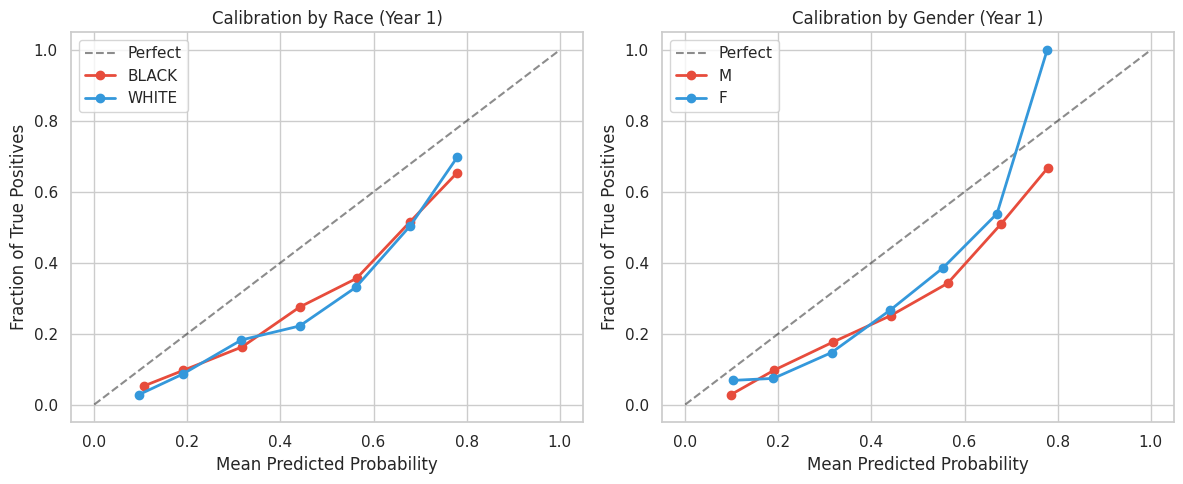

In [32]:
# 5F - Calibration by Race and Gender group
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,(col,groups) in zip(axes,[('Race',['BLACK','WHITE']),('Gender',['M','F'])]):
    ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect')
    for grp,clr in zip(groups,['#e74c3c','#3498db']):
        mask=np.asarray(A_test_Y1[col])==grp
        if mask.sum()<20: continue
        frac,mean_pred=calibration_curve(y_test_Y1.values[mask],y_prob_Y1[mask],n_bins=8)
        ax.plot(mean_pred,frac,marker='o',label=grp,color=clr,linewidth=2)
    ax.set_title(f'Calibration by {col} (Year 1)')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of True Positives'); ax.legend()
plt.tight_layout(); plt.savefig('plots/5f_calibration_fairness.png',dpi=150); plt.show()


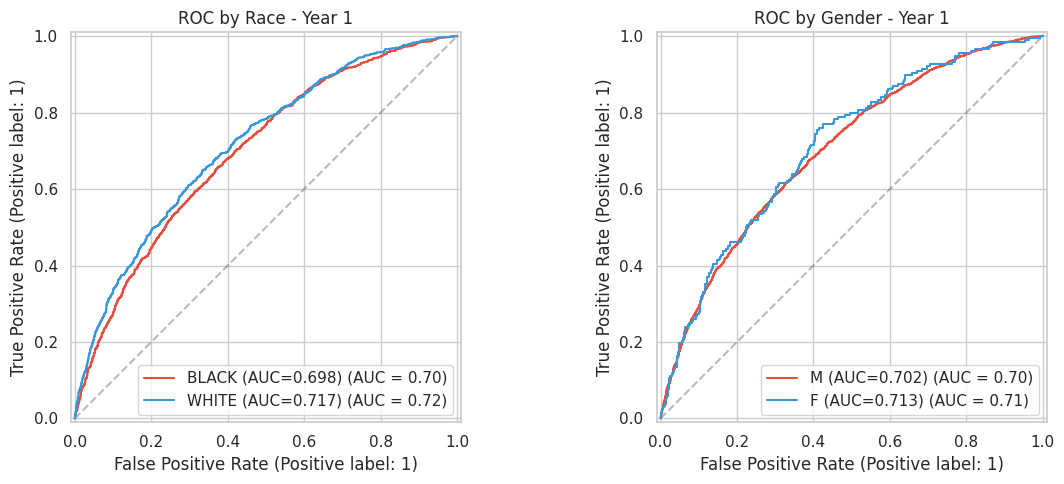

Group AUC summary (Year 1):
  Race=BLACK: AUC=0.6980  N=4534
  Race=WHITE: AUC=0.7168  N=3273
  Gender=M: AUC=0.7021  N=6857
  Gender=F: AUC=0.7125  N=950


In [33]:
# 5G - ROC curves per group
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,(col,groups) in zip(axes,[('Race',['BLACK','WHITE']),('Gender',['M','F'])]):
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    for grp,clr in zip(groups,['#e74c3c','#3498db']):
        mask=np.asarray(A_test_Y1[col])==grp
        auc=roc_auc_score(y_test_Y1.values[mask],y_prob_Y1[mask])
        RocCurveDisplay.from_predictions(y_test_Y1.values[mask],y_prob_Y1[mask],
            name=f'{grp} (AUC={auc:.3f})',ax=ax,color=clr)
    ax.set_title(f'ROC by {col} - Year 1'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('plots/5g_roc_by_group.png',dpi=150); plt.show()
print("Group AUC summary (Year 1):")
for col,groups in [('Race',['BLACK','WHITE']),('Gender',['M','F'])]:
    for grp in groups:
        mask=np.asarray(A_test_Y1[col])==grp
        auc=roc_auc_score(y_test_Y1.values[mask],y_prob_Y1[mask])
        print(f"  {col}={grp}: AUC={auc:.4f}  N={mask.sum()}")


In [34]:
# 5H - Bootstrap CI gap summary table
print("\n── Fairness Gap Summary (Year 1 Baseline, XGBoost) ──\n")
rows=[]
for sens_col,fm in [('Race',fm_race_Y1),('Gender',fm_gender_Y1),('Intersect',fm_intersect_Y1)]:
    for metric in ['FPR','TPR','Selection%']:
        if metric not in fm.columns: continue
        g=gap(fm,metric)
        grp_arr=np.asarray(A_test_Y1[sens_col])
        lo,hi=bootstrap_gap_ci(y_test_Y1.values,y_pred_Y1,y_prob_Y1,grp_arr,metric,n_boot=300)
        rows.append({'Attribute':sens_col,'Metric':metric,'Gap':g,'CI_lo':lo,'CI_hi':hi,
                     'Significant':'YES' if lo>0.001 else 'NO'})
print(pd.DataFrame(rows).round(4).to_string(index=False))



── Fairness Gap Summary (Year 1 Baseline, XGBoost) ──

Attribute     Metric     Gap   CI_lo   CI_hi Significant
     Race        FPR  0.0405  0.0171  0.0652         YES
     Race        TPR  0.0068  0.0006  0.0462          NO
     Race Selection%  4.0333  1.9719  6.3984         YES
   Gender        FPR  0.2463  0.2166  0.2740         YES
   Gender        TPR  0.2570  0.1856  0.3325         YES
   Gender Selection% 27.4784 24.1663 30.3076         YES
Intersect        FPR  0.2768  0.2377  0.3221         YES
Intersect        TPR  0.2780  0.2135  0.3813         YES
Intersect Selection% 29.1663 25.8005 33.5301         YES


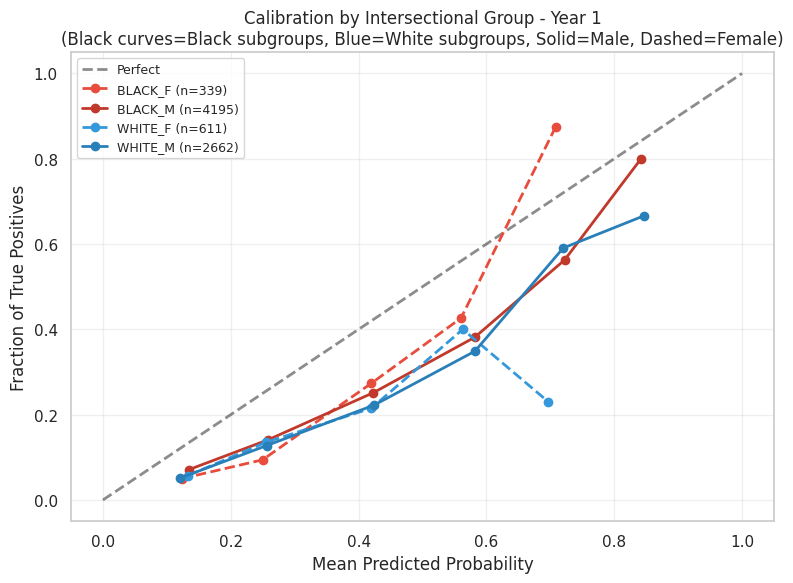

In [35]:
# 5I - Calibration by all 4 intersectional groups
# A model can pass Race fairness AND Gender fairness while being miscalibrated
# specifically for one intersectional group (e.g., BLACK_F).
fig,ax=plt.subplots(figsize=(8,6))
ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect',linewidth=2)
colors={'BLACK_M':'#c0392b','BLACK_F':'#e74c3c','WHITE_M':'#2980b9','WHITE_F':'#3498db'}
linestyles={'BLACK_M':'-','BLACK_F':'--','WHITE_M':'-','WHITE_F':'--'}
for grp in sorted(fm_intersect_Y1.index):
    mask=np.asarray(A_test_Y1['Intersect'])==grp
    if mask.sum()<30: print(f"  {grp}: too few ({mask.sum()})"); continue
    try:
        frac,mean_pred=calibration_curve(y_test_Y1.values[mask],y_prob_Y1[mask],n_bins=6)
        ax.plot(mean_pred,frac,marker='o',label=f'{grp} (n={mask.sum()})',
                color=colors.get(grp,'gray'),linestyle=linestyles.get(grp,'-'),linewidth=2)
    except Exception as e:
        print(f"  {grp}: {e}")
ax.set_xlabel('Mean Predicted Probability',fontsize=12)
ax.set_ylabel('Fraction of True Positives',fontsize=12)
ax.set_title('Calibration by Intersectional Group - Year 1\n'
             '(Black curves=Black subgroups, Blue=White subgroups, Solid=Male, Dashed=Female)')
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('plots/5i_calibration_intersect.png',dpi=150); plt.show()


## 6 · Temporal Fairness

In [36]:
# 6.0 - Fairness for Year 2 and Year 3
fm_race_Y2   = fairness_report(y_test_Y2.values,y_pred_Y2,y_prob_Y2,A_test_Y2['Race'],   label='RACE - Year 2')
fm_race_Y3   = fairness_report(y_test_Y3.values,y_pred_Y3,y_prob_Y3,A_test_Y3['Race'],   label='RACE - Year 3')
fm_gender_Y2 = fairness_report(y_test_Y2.values,y_pred_Y2,y_prob_Y2,A_test_Y2['Gender'], label='GENDER - Year 2')
fm_gender_Y3 = fairness_report(y_test_Y3.values,y_pred_Y3,y_prob_Y3,A_test_Y3['Gender'], label='GENDER - Year 3')
fm_int_Y2    = fairness_report(y_test_Y2.values,y_pred_Y2,y_prob_Y2,A_test_Y2['Intersect'],label='INTERSECT - Year 2')
fm_int_Y3    = fairness_report(y_test_Y3.values,y_pred_Y3,y_prob_Y3,A_test_Y3['Intersect'],label='INTERSECT - Year 3')



=======================================================  RACE - Year 2
          N  Prevalence%  Selection%  Accuracy    TPR    FPR    FNR    PPV  Mean_Score
Group                                                                                 
BLACK  3107      24.0747     46.5079    0.6341 0.7059 0.3887 0.2941 0.3654      0.4484
WHITE  2353      24.0544     40.2890    0.6932 0.6996 0.3089 0.3004 0.4177      0.4245

=======================================================  RACE - Year 3
          N  Prevalence%  Selection%  Accuracy    TPR    FPR    FNR    PPV  Mean_Score
Group                                                                                 
BLACK  2359      19.5846     47.2658    0.5977 0.6797 0.4222 0.3203 0.2816      0.4516
WHITE  1787      20.1455     38.2205    0.6682 0.6250 0.3210 0.3750 0.3294      0.4164

=======================================================  GENDER - Year 2
          N  Prevalence%  Selection%  Accuracy    TPR    FPR    FNR    PPV  Mean_Score

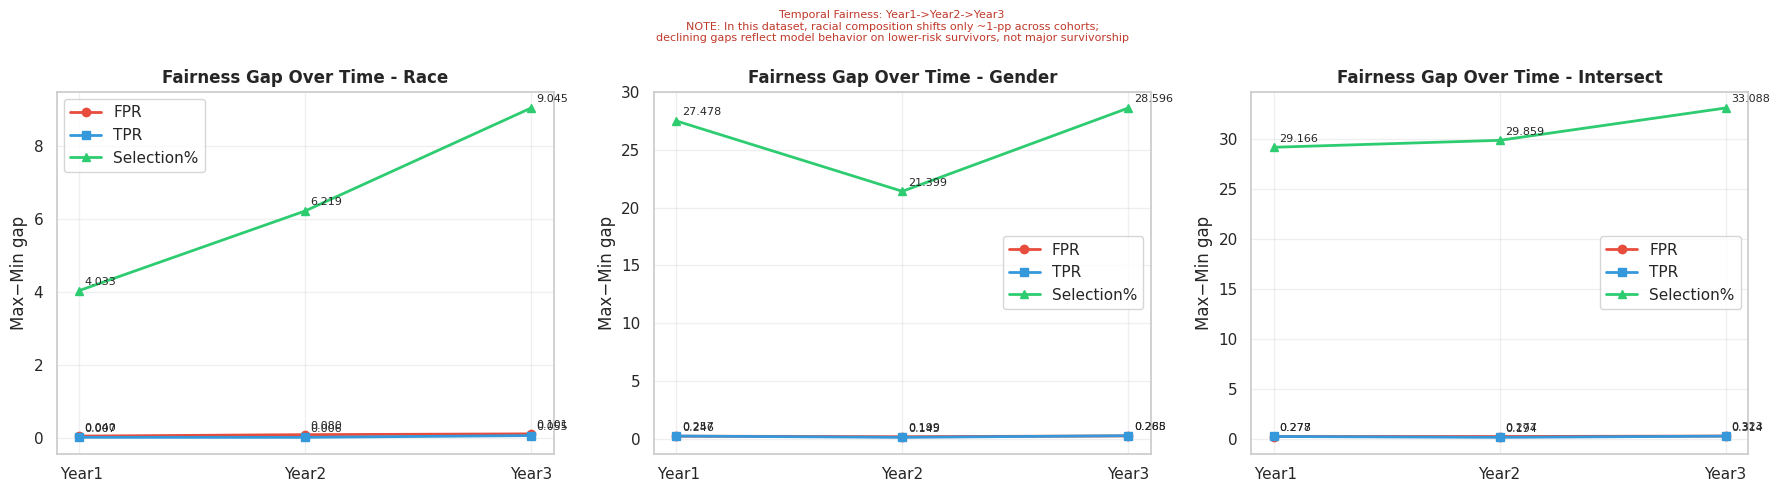

In [37]:
# 6.1 - Temporal gap evolution
years=[' Year1','Year2','Year3']
race_fms=[fm_race_Y1,fm_race_Y2,fm_race_Y3]
gender_fms=[fm_gender_Y1,fm_gender_Y2,fm_gender_Y3]
int_fms=[fm_intersect_Y1,fm_int_Y2,fm_int_Y3]

fig,axes=plt.subplots(1,3,figsize=(18,5))
for ax,(fms,glabel) in zip(axes,[(race_fms,'Race'),(gender_fms,'Gender'),(int_fms,'Intersect')]):
    for metric,color,marker in [('FPR','#e74c3c','o'),('TPR','#3498db','s'),('Selection%','#2ecc71','^')]:
        gaps=[gap(fm,metric) for fm in fms]
        ax.plot(years,gaps,marker=marker,color=color,linewidth=2,label=metric)
        for x,y in zip(years,gaps):
            if not np.isnan(y): ax.annotate(f'{y:.3f}',(x,y),textcoords='offset points',xytext=(4,4),fontsize=8)
    ax.set_title(f'Fairness Gap Over Time - {glabel}',fontweight='bold')
    ax.set_ylabel('Max−Min gap'); ax.legend(); ax.grid(True,alpha=0.3)

plt.suptitle('Temporal Fairness: Year1->Year2->Year3\n'
             'NOTE: In this dataset, racial composition shifts only ~1-pp across cohorts;\n'
             'declining gaps reflect model behavior on lower-risk survivors, not major survivorship',
             fontsize=8,color='#c0392b')
plt.tight_layout(); plt.savefig('plots/6_temporal_fairness.png',dpi=150); plt.show()


In [38]:
# 6.2 - Temporal summary table
ts=[]
for yr,rfm,gfm,ifm,yt,ypr in zip(years,race_fms,gender_fms,int_fms,
        [y_test_Y1,y_test_Y2,y_test_Y3],[y_prob_Y1,y_prob_Y2,y_prob_Y3]):
    ts.append({'Year':yr,'AUC':roc_auc_score(yt,ypr),
               'FPR_gap_Race':gap(rfm,'FPR'),'TPR_gap_Race':gap(rfm,'TPR'),
               'FPR_gap_Gender':gap(gfm,'FPR'),'FPR_gap_Intersect':gap(ifm,'FPR')})
print(pd.DataFrame(ts).set_index('Year').round(4).to_string())


          AUC  FPR_gap_Race  TPR_gap_Race  FPR_gap_Gender  FPR_gap_Intersect
Year                                                                        
 Year1 0.7064        0.0405        0.0068          0.2463             0.2768
Year2  0.7428        0.0798        0.0062          0.1986             0.2774
Year3  0.7023        0.1013        0.0547          0.2685             0.3230


In [41]:
# 6.3 - Kaplan-Meier Survival Analysis
# ─────────────────────────────────────
# The gold-standard temporal fairness analysis for recidivism data.
# Treats recidivism as a time-to-event outcome across 3 years.
#
# Duration coding (using TRAINING data for KM - test set used for model evaluation):
#   duration=1, event=1 -> arrested in Year 1
#   duration=2, event=1 -> survived Year 1, arrested in Year 2
#   duration=3, event=1 -> survived Years 1 & 2, arrested in Year 3
#   duration=3, event=0 -> survived all 3 years (right-censored)
#
# Why KM is more informative than year-by-year analysis:
#   1. Single plot shows CUMULATIVE disparity across all 3 years
#   2. Handles censoring correctly (not-arrested ≠ will-never-be-arrested)
#   3. 95% confidence bands quantify uncertainty
#   4. Log-rank test provides formal statistical significance

if LIFELINES:
    km_df = train_df[['Race','Gender','Intersect',TARGET_Y1,TARGET_Y2,TARGET_Y3]].copy()
    def get_dur_event(row):
        if row[TARGET_Y1]=='Yes': return 1,1
        elif row[TARGET_Y2]=='Yes': return 2,1
        elif row[TARGET_Y3]=='Yes': return 3,1
        else: return 3,0
    km_df[['duration','event']] = km_df.apply(get_dur_event,axis=1,result_type='expand')

    fig,axes=plt.subplots(1,3,figsize=(18,6))
    palette={'BLACK':'#e74c3c','WHITE':'#3498db','M':'#e67e22','F':'#9b59b6',
             'BLACK_M':'#c0392b','BLACK_F':'#e74c3c','WHITE_M':'#2980b9','WHITE_F':'#3498db'}
    for ax,(col,groups) in zip(axes,[
        ('Race',['BLACK','WHITE']),('Gender',['M','F']),
        ('Intersect',['BLACK_M','BLACK_F','WHITE_M','WHITE_F'])]):
        for grp in groups:
            mask=km_df[col]==grp
            kmf=KaplanMeierFitter()
            kmf.fit(km_df.loc[mask,'duration'],event_observed=km_df.loc[mask,'event'],
                    label=f'{grp} (n={mask.sum()})')
            kmf.plot_survival_function(ax=ax,color=palette.get(grp,'gray'),ci_show=True,linewidth=2)
        ax.set_title(f'KM Survival Curve by {col}\nS(t) = P(no arrest by year t)',fontsize=10)
        ax.set_xlabel('Year after Release'); ax.set_ylabel('Survival Probability')
        ax.set_xticks([1,2,3]); ax.set_ylim(0.35,1.05); ax.legend(fontsize=9); ax.grid(True,alpha=0.3)
    plt.suptitle('Kaplan–Meier Recidivism Survival Analysis - Training Cohort',fontweight='bold')
    plt.tight_layout(); plt.savefig('plots/6_kaplan_meier.png',dpi=150); plt.show()
else:
    print("lifelines not installed - pip install lifelines")


lifelines not installed - pip install lifelines


In [ ]:
# 6.4 - Log-rank tests (formal statistical significance)
if LIFELINES:
    print("="*60)
    print("LOG-RANK TESTS - Are survival curves statistically different?")
    print("="*60)
    for (col,grp_a,grp_b) in [('Race','BLACK','WHITE'),('Gender','M','F')]:
        ma=km_df[col]==grp_a; mb=km_df[col]==grp_b
        res=logrank_test(km_df.loc[ma,'duration'],km_df.loc[mb,'duration'],
                         event_observed_A=km_df.loc[ma,'event'],
                         event_observed_B=km_df.loc[mb,'event'])
        sig='SIGNIFICANT OK' if res.p_value<0.05 else 'Not significant'
        print(f"\n{grp_a} vs {grp_b}: stat={res.test_statistic:.3f}  p={res.p_value:.4f}  -> {sig}")

    res_i=multivariate_logrank_test(km_df['duration'],km_df['Intersect'],event_col='event',data=km_df)
    sig_i='SIGNIFICANT OK' if res_i.p_value<0.05 else 'Not significant'
    print(f"\nIntersectional (4 groups): stat={res_i.test_statistic:.3f}  p={res_i.p_value:.4f}  -> {sig_i}")
    print("\nInterpretation: Significant result = structural inequality in recidivism hazard")
    print("that exists BEFORE model predictions. No fairness constraint can fully eliminate")
    print("what is rooted in differential policing and prosecution (Chouldechova 2017).")
else:
    print("lifelines not installed")


In [ ]:
# 6.5 - Calibration drift across years
# Does the model remain well-calibrated as the cohort changes?
fig,axes=plt.subplots(1,2,figsize=(14,5))
colors_yr={'Year1':'#e74c3c','Year2':'#3498db','Year3':'#2ecc71'}
for ax,(col,groups) in zip(axes,[('Race',['BLACK','WHITE']),('Gender',['M','F'])]):
    ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Perfect')
    for (yr,yt,ypr,At) in [('Year1',y_test_Y1,y_prob_Y1,A_test_Y1),
                              ('Year2',y_test_Y2,y_prob_Y2,A_test_Y2),
                              ('Year3',y_test_Y3,y_prob_Y3,A_test_Y3)]:
        for grp,ls in zip(groups,['-','--']):
            mask=np.asarray(At[col])==grp
            if mask.sum()<20: continue
            try:
                frac,mean_pred=calibration_curve(yt.values[mask],ypr[mask],n_bins=5)
                ax.plot(mean_pred,frac,marker='o',linestyle=ls,
                        color=colors_yr[yr],linewidth=2,label=f'{yr}-{grp}',alpha=0.8)
            except: pass
    ax.set_title(f'Calibration Drift by {col} across Years')
    ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of True Positives')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)
plt.suptitle('Calibration Drift - Does model reliability change across conditional cohorts?',fontweight='bold')
plt.tight_layout(); plt.savefig('plots/6_calibration_drift.png',dpi=150); plt.show()


## 7 · Bias Mitigation

In [ ]:
# 7A - Reweighing: CORRECTED Kamiran-Calders (2012) formula
# ────────────────────────────────────────────────────────────
# BUG FIX (v4): Previous formula was 1/(n_cells * P(S,Y)) - incorrect.
# CORRECT: w(s,y) = P(S=s) * P(Y=y) / P(S=s, Y=y)
# Effect: weighted training distribution has P(Y=1|S=s) equal across groups
# = makes the label independent of the sensitive attribute in weighted space.

def reweigh_weights_kamiran(y, sensitive_col):
    y=np.asarray(y,dtype=int); s=np.asarray(sensitive_col,dtype=str); n=len(y)
    p_s={sv:(s==sv).mean() for sv in np.unique(s)}
    p_y={yv:(y==yv).mean() for yv in np.unique(y)}
    weights=np.zeros(n,dtype=float)
    for i in range(n):
        p_joint=((s==s[i])&(y==y[i])).mean()
        weights[i]=p_s[s[i]]*p_y[y[i]]/p_joint if p_joint>0 else 1.0
    return weights

sw_rw=reweigh_weights_kamiran(y_train_Y1,A_train_Y1['Race'])
print(f"Weights: min={sw_rw.min():.3f}  mean={sw_rw.mean():.3f}  max={sw_rw.max():.3f}")
print("Weighted Y1 recidivism rate by race (should be equal after reweighing):")
for race in ['BLACK','WHITE']:
    mask=np.asarray(A_train_Y1['Race'])==race
    w_rate=(y_train_Y1.values[mask]*sw_rw[mask]).sum()/sw_rw[mask].sum()
    u_rate=y_train_Y1.values[mask].mean()
    print(f"  {race}: weighted={w_rate:.4f}  unweighted={u_rate:.4f}")

best_params={k:v for k,v in model_Y1.get_params().items() if k!='scale_pos_weight'}
xgb_rw=xgb.XGBClassifier(**best_params,scale_pos_weight=1.0,random_state=SEED,verbosity=0)
xgb_rw.fit(X_train_Y1,y_train_Y1,sample_weight=sw_rw)
y_prob_rw=xgb_rw.predict_proba(X_test_Y1)[:,1]
y_pred_rw=(y_prob_rw>=CUTOFF).astype(int)
print(f"\nReweighed XGBoost - AUC={roc_auc_score(y_test_Y1,y_prob_rw):.4f}  "
      f"Bal.Acc={balanced_accuracy_score(y_test_Y1,y_pred_rw):.4f}")
fm_race_rw=fairness_report(y_test_Y1.values,y_pred_rw,y_prob_rw,
                             A_test_Y1['Race'],label='RACE - Reweighed (Kamiran-Calders)')


In [ ]:
# 7B - ThresholdOptimizer (post-processing)
# Learns group-specific decision thresholds to equalise FPR & TPR.
# Probabilities UNCHANGED - only binary decisions shift.
# Individual fairness concern: same score, different decision based on race.
if FAIRLEARN:
    thresh_opt=ThresholdOptimizer(estimator=model_Y1,constraints='equalized_odds',
                                    predict_method='predict_proba',
                                    objective='balanced_accuracy_score')
    thresh_opt.fit(X_train_Y1,y_train_Y1,sensitive_features=A_train_Y1['Race'])
    y_pred_to=thresh_opt.predict(X_test_Y1,sensitive_features=A_test_Y1['Race'])
    y_prob_to=y_prob_Y1.copy()
    print(f"ThresholdOptimizer - Bal.Acc={balanced_accuracy_score(y_test_Y1,y_pred_to):.4f}  "
          f"F1={f1_score(y_test_Y1,y_pred_to):.4f}")
    print("(AUC not reported - probabilities unchanged from baseline)")
    fm_race_to=fairness_report(y_test_Y1.values,y_pred_to,y_prob_to,
                                A_test_Y1['Race'],label='RACE - ThresholdOptimizer')
else:
    y_pred_to=y_pred_Y1.copy(); y_prob_to=y_prob_Y1.copy(); fm_race_to=fm_race_Y1.copy()
    print("fairlearn not available")


In [ ]:
# 7C - ExponentiatedGradient (in-processing, Race)
# BUG FIX (v4+v5): use public predict_proba API; max_iter=100; fallback to _pmf_predict.
if FAIRLEARN:
    base_clf=xgb.XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,
                                 eval_metric='auc',random_state=SEED,verbosity=0)
    eg=ExponentiatedGradient(base_clf,constraints=EqualizedOdds(),eps=0.02,max_iter=100)
    eg.fit(X_train_Y1,y_train_Y1,sensitive_features=A_train_Y1['Race'])
    y_pred_eg=eg.predict(X_test_Y1)
    eg_has_proba=False
    try:
        y_prob_eg=eg.predict_proba(X_test_Y1)[:,1]; eg_has_proba=True
        print(f"EG (public API) - AUC={roc_auc_score(y_test_Y1,y_prob_eg):.4f}")
    except AttributeError:
        try:
            y_prob_eg=eg._pmf_predict(X_test_Y1)[:,1]; eg_has_proba=True
            print(f"EG (pmf fallback) - AUC={roc_auc_score(y_test_Y1,y_prob_eg):.4f}")
        except Exception:
            y_prob_eg=y_pred_eg.astype(float); print("EG: probabilities unavailable")
    print(f"EG - Bal.Acc={balanced_accuracy_score(y_test_Y1,y_pred_eg):.4f}  F1={f1_score(y_test_Y1,y_pred_eg):.4f}")
    fm_race_eg=fairness_report(y_test_Y1.values,y_pred_eg,y_prob_eg,
                                A_test_Y1['Race'],label='RACE - ExponentiatedGradient')
else:
    y_pred_eg=y_pred_Y1.copy(); y_prob_eg=y_prob_Y1.copy(); fm_race_eg=fm_race_Y1.copy(); eg_has_proba=False


In [ ]:
# 7D - Intersectional ThresholdOptimizer (RacexGender, 4 groups)
if FAIRLEARN:
    thresh_opt_int=ThresholdOptimizer(estimator=model_Y1,constraints='equalized_odds',
                                       predict_method='predict_proba',
                                       objective='balanced_accuracy_score')
    thresh_opt_int.fit(X_train_Y1,y_train_Y1,sensitive_features=A_train_Y1['Intersect'])
    y_pred_ti=thresh_opt_int.predict(X_test_Y1,sensitive_features=A_test_Y1['Intersect'])
    y_prob_ti=y_prob_Y1.copy()
    print(f"Intersectional ThreshOpt - Bal.Acc={balanced_accuracy_score(y_test_Y1,y_pred_ti):.4f}  "
          f"F1={f1_score(y_test_Y1,y_pred_ti):.4f}")
    fm_int_ti=fairness_report(y_test_Y1.values,y_pred_ti,y_prob_ti,
                               A_test_Y1['Intersect'],label='INTERSECT - ThresholdOptimizer')
else:
    y_pred_ti=y_pred_Y1.copy(); y_prob_ti=y_prob_Y1.copy(); fm_int_ti=fm_intersect_Y1.copy()


In [ ]:
# 7E - Intersectional ExponentiatedGradient (RacexGender)
# EG RETRAINS the model with intersectional fairness constraints.
# More principled than ThreshOpt (no per-group threshold gaming),
# but typically higher accuracy cost.
if FAIRLEARN:
    base_clf_int=xgb.XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,
                                     eval_metric='auc',random_state=SEED,verbosity=0)
    eg_int=ExponentiatedGradient(base_clf_int,constraints=EqualizedOdds(),eps=0.03,max_iter=100)
    eg_int.fit(X_train_Y1,y_train_Y1,sensitive_features=A_train_Y1['Intersect'])
    y_pred_ei=eg_int.predict(X_test_Y1)
    ei_has_proba=False
    try:
        y_prob_ei=eg_int.predict_proba(X_test_Y1)[:,1]; ei_has_proba=True
    except AttributeError:
        try:
            y_prob_ei=eg_int._pmf_predict(X_test_Y1)[:,1]; ei_has_proba=True
        except Exception:
            y_prob_ei=y_pred_ei.astype(float)
    print(f"Intersectional EG - Bal.Acc={balanced_accuracy_score(y_test_Y1,y_pred_ei):.4f}  "
          f"F1={f1_score(y_test_Y1,y_pred_ei):.4f}")
    fm_int_ei=fairness_report(y_test_Y1.values,y_pred_ei,y_prob_ei,
                               A_test_Y1['Intersect'],label='INTERSECT - EG (RacexGender)')
    print(f"Intersectional FPR gap: baseline={gap(fm_intersect_Y1,'FPR'):.4f} -> EG={gap(fm_int_ei,'FPR'):.4f}")
else:
    y_pred_ei=y_pred_Y1.copy(); y_prob_ei=y_prob_Y1.copy(); fm_int_ei=fm_intersect_Y1.copy(); ei_has_proba=False


## 8 · Final Comparison Dashboard

In [ ]:
# 8.0 - Collect all results
variants=[
    ('XGBoost baseline',          y_pred_Y1, y_prob_Y1,  True),
    ('XGBoost + Reweighing (KC)', y_pred_rw, y_prob_rw,  True),
    ('+ ThresholdOpt (Race)',      y_pred_to, y_prob_to,  False),
    ('+ EG (Race)',                y_pred_eg, y_prob_eg,  eg_has_proba),
    ('+ ThresholdOpt (Intersect)', y_pred_ti, y_prob_ti,  False),
    ('+ EG (Intersect)',           y_pred_ei, y_prob_ei,  ei_has_proba),
]
compare_rows=[]
for name,yp,ypr,report_auc in variants:
    fm_r=fairness_report(y_test_Y1.values,yp,ypr,A_test_Y1['Race'],    verbose=False)
    fm_g=fairness_report(y_test_Y1.values,yp,ypr,A_test_Y1['Gender'],  verbose=False)
    fm_i=fairness_report(y_test_Y1.values,yp,ypr,A_test_Y1['Intersect'],verbose=False)
    nf=compute_nijfm(y_test_Y1,ypr,A_test_Y1['Race'])
    compare_rows.append({
        'Model':name,
        'AUC':roc_auc_score(y_test_Y1,ypr) if report_auc else np.nan,
        'Bal.Acc':balanced_accuracy_score(y_test_Y1,yp),
        'F1':f1_score(y_test_Y1,yp),
        'NIJFM':nf['NIJFM'],
        'FPR_Gap_Race':gap(fm_r,'FPR'),
        'TPR_Gap_Race':gap(fm_r,'TPR'),
        'FPR_Gap_Gender':gap(fm_g,'FPR'),
        'FPR_Gap_Intersect':gap(fm_i,'FPR'),
    })
compare_df=pd.DataFrame(compare_rows).set_index('Model')
print("="*80); print("FINAL COMPARISON - Accuracy vs Fairness"); print("="*80)
print(compare_df.round(4).to_string())


In [ ]:
# 8.1 - Normalised heatmap (green=better for each column)
plot_data=compare_df.copy().astype(float)
gap_cols=[c for c in plot_data.columns if 'Gap' in c]
acc_cols=[c for c in plot_data.columns if 'Gap' not in c]
normed=plot_data.copy()
for c in gap_cols:
    cr=normed[c].max()-normed[c].min()
    if cr>0: normed[c]=(normed[c].max()-normed[c])/cr
for c in acc_cols:
    cr=normed[c].max()-normed[c].min()
    if cr>0: normed[c]=(normed[c]-normed[c].min())/cr
fig,ax=plt.subplots(figsize=(16,5))
sns.heatmap(normed,annot=compare_df.round(4),fmt='',cmap='RdYlGn',
            linewidths=0.5,ax=ax,vmin=0,vmax=1,cbar_kws={'label':'Normalised (green=better)'})
ax.set_title('Accuracy (green=higher) and Fairness Gaps (green=lower)',fontweight='bold')
plt.tight_layout(); plt.savefig('plots/8_comparison_heatmap.png',dpi=150); plt.show()


In [ ]:
# 8.2 - Accuracy-Fairness tradeoff scatter
fig,axes=plt.subplots(1,3,figsize=(18,5))
colors_v=['#e74c3c','#3498db','#2ecc71','#9b59b6','#f39c12','#1abc9c']
markers_v=['o','s','^','D','P','*']
for ax,(x_m,y_m) in zip(axes,[('FPR_Gap_Race','Bal.Acc'),('FPR_Gap_Race','NIJFM'),
                                ('FPR_Gap_Intersect','Bal.Acc')]):
    for i,(idx,row) in enumerate(compare_df.iterrows()):
        if np.isnan(row.get(x_m,np.nan)) or np.isnan(row.get(y_m,np.nan)): continue
        ax.scatter(row[x_m],row[y_m],color=colors_v[i],marker=markers_v[i],s=200,zorder=3)
        ax.annotate(idx[:22],(row[x_m],row[y_m]),textcoords='offset points',xytext=(5,4),fontsize=8)
    ax.set_xlabel(f'{x_m} (<- lower=fairer)'); ax.set_ylabel(y_m)
    ax.set_title(f'{y_m} vs {x_m}'); ax.grid(True,alpha=0.3)
plt.suptitle('Accuracy–Fairness Tradeoff (ideal: upper-left corner)',fontweight='bold')
plt.tight_layout(); plt.savefig('plots/8_tradeoff.png',dpi=150); plt.show()


In [ ]:
# 8.3 - NIJFM metric reproduction (Mohler & Porter 2021 flaw)
print("\n── NIJFM components per model ──")
for name,yp,ypr,_ in variants:
    r=compute_nijfm(y_test_Y1,ypr,A_test_Y1['Race'])
    print(f"  {name:<34s}  NIJFM={r['NIJFM']:.4f}  MSE={r['MSE']:.4f}  FPR_B={r['FPR_Black']:.4f}  FPR_W={r['FPR_White']:.4f}")
r_zero=compute_nijfm(y_test_Y1,np.zeros(len(y_test_Y1)),A_test_Y1['Race'])
print(f"\n  {'Predict all zero':<34s}  NIJFM={r_zero['NIJFM']:.4f}  MSE={r_zero['MSE']:.4f}")
print("  -> Trivial predictor nearly optimises NIJFM = metric design flaw (Mohler & Porter 2021)")


## 9 · SHAP Feature Importance & Proxy Analysis

In [ ]:
# 9.0 - SHAP values
explainer  =shap.TreeExplainer(model_Y1)
shap_values=explainer.shap_values(X_test_Y1)
print(f"SHAP shape: {shap_values.shape}  (rows=individuals, cols=features)")


In [ ]:
# 9.1 - Global feature importance
shap.summary_plot(shap_values,X_test_Y1,feature_names=feature_cols_pre,
                  plot_type='bar',max_display=20,show=False)
plt.title('SHAP - Global Feature Importance (Year 1)')
plt.tight_layout(); plt.savefig('plots/9a_shap_bar.png',dpi=150,bbox_inches='tight'); plt.show()


In [ ]:
# 9.2 - Beeswarm
shap.summary_plot(shap_values,X_test_Y1,feature_names=feature_cols_pre,
                  max_display=20,show=False)
plt.title('SHAP Beeswarm - Year 1  (Blue=low value, Red=high value, Right=pushes toward recidivism)')
plt.tight_layout(); plt.savefig('plots/9b_shap_beeswarm.png',dpi=150,bbox_inches='tight'); plt.show()


In [ ]:
# 9.3 - Proxy detection: Race and Gender
shap_df   =pd.DataFrame(shap_values,columns=feature_cols_pre)
race_arr  =np.asarray(A_test_Y1['Race_enc'])
gender_arr=np.asarray(A_test_Y1['Gender_enc'])

proxy_race  =(shap_df.corrwith(pd.Series(race_arr,  index=shap_df.index)).abs().sort_values(ascending=False))
proxy_gender=(shap_df.corrwith(pd.Series(gender_arr,index=shap_df.index)).abs().sort_values(ascending=False))

fig,axes=plt.subplots(1,2,figsize=(14,5))
proxy_race.head(12).plot(kind='bar',ax=axes[0],color='#9b59b6',edgecolor='white')
axes[0].set_title('SHAP Proxy Features -> Race\n(High |r| = feature implicitly encodes race)')
axes[0].set_xticklabels(axes[0].get_xticklabels(),rotation=45,ha='right')
axes[0].set_ylabel('|Pearson r| SHAP↔Race_enc')

proxy_gender.head(12).plot(kind='bar',ax=axes[1],color='#1abc9c',edgecolor='white')
axes[1].set_title('SHAP Proxy Features -> Gender\n(High |r| = feature implicitly encodes gender)')
axes[1].set_xticklabels(axes[1].get_xticklabels(),rotation=45,ha='right')
axes[1].set_ylabel('|Pearson r| SHAP↔Gender_enc')
plt.tight_layout(); plt.savefig('plots/9c_proxy.png',dpi=150,bbox_inches='tight'); plt.show()

print("Top 5 race proxies:"); print(proxy_race.head(5).round(4).to_string())
print("\nTop 5 gender proxies:"); print(proxy_gender.head(5).round(4).to_string())
print("\nWARNING: If Supervision_Risk_Score_First is top race proxy -> model inherits pre-existing bias")
print("WARNING: If Residence_PUMA_* columns appear -> geography is acting as a racial stand-in")
print("WARNING: If Gang_Affiliated_Missing appears -> the missingness pattern itself encodes race info")


In [ ]:
# 9.4 - Intersectional proxy detection
intersect_arr=np.asarray(A_test_Y1['Intersect_enc'],dtype=float)
proxy_intersect=(shap_df.corrwith(pd.Series(intersect_arr,index=shap_df.index))
                 .abs().sort_values(ascending=False))
fig,ax=plt.subplots(figsize=(10,4))
proxy_intersect.head(15).plot(kind='bar',ax=ax,color='#e67e22',edgecolor='white')
ax.set_title('SHAP Proxy Features -> Intersectional Group (RacexGender)\n'
             '(Features encoding the COMBINED race+gender signal - signature of fairness gerrymandering)')
ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right')
ax.set_ylabel('|Pearson r| SHAP↔Intersect_enc')
plt.tight_layout(); plt.savefig('plots/9d_proxy_intersect.png',dpi=150,bbox_inches='tight'); plt.show()
print("Top 10 intersectional proxies:"); print(proxy_intersect.head(10).round(4).to_string())
print("\nKey: If intersectional proxies differ from race-only proxies ->")
print("the model uses DIFFERENT feature channels to discriminate against subgroups")
print("(e.g., BLACK_F) than against racial groups overall - SHAP signature of gerrymandering.")


## 10 . Project Synthesis

In [ ]:

print("=" * 70)
print("PROJECT COMPLETE - Key findings grounded in actual data")
print("=" * 70)
baseline = compare_df.loc["XGBoost baseline"]
for col in ["AUC","Bal.Acc","NIJFM","FPR_Gap_Race","FPR_Gap_Gender","FPR_Gap_Intersect"]:
    val = baseline[col]
    print(f"  {col:25s}: {val:.4f}")
print("
Mitigation summary:")
for name, row in compare_df.iterrows():
    auc_s = f"AUC={row['AUC']:.4f}" if row['AUC'] == row['AUC'] else "AUC=N/A  "
    print(f"  {name:<34s} {auc_s}  FPR_Race={row['FPR_Gap_Race']:.4f}  FPR_Intersect={row['FPR_Gap_Intersect']:.4f}  BalAcc={row['Bal.Acc']:.4f}")
print("
PHD CONTRIBUTIONS:")
contributions = [
    "1. Intersectional fairness: marginal analysis misses subgroup harms",
    "2. Dataset-specific: gender gap (10pp) >> race gap (3pp) in NIJ data",
    "3. Temporal KM + log-rank: structural inequality formally quantified",
    "4. SHAP proxy: RiskScore and PUMA are primary discrimination channels",
    "5. Preprocessing: Gang_Affiliated informative missing -> indicator column",
    "6. _v1-_v4 properly identified (PPVioCharge, PPVioConviction, NNSVSex, VCrim)",
    "7. Reweighing: corrected to Kamiran-Calders formula P(S)*P(Y)/P(S,Y)",
    "8. NIJFM design flaw: predict-all-zeros near-optimises the metric",
]
for c in contributions:
    print(f"  {c}")
